In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

In [ ]:
import os
os.listdir("sample_data")

['README.md',
 'anscombe.json',
 'mnist_test.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'california_housing_test.csv']

In [ ]:
import os
os.listdir("sample_data")

['README.md',
 'anscombe.json',
 'mnist_test.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'california_housing_test.csv']

In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE122nnn/GSE122063/matrix/GSE122063_series_matrix.txt.gz

--2026-09-09 12:39:54--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE122nnn/GSE122063/matrix/GSE122063_series_matrix.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38583703 (37M) [application/x-gzip]
Saving to: ‘GSE122063_series_matrix.txt.gz’

GSE122063_series_ma 100%[===================>]  36.80M  47.9MB/s    in 0.8s    

2026-09-09 12:39:55 (47.9 MB/s) - ‘GSE122063_series_matrix.txt.gz’ saved [38583703/38583703]



In [ ]:
import os
os.listdir()

['.config', 'GSE122063_series_matrix.txt.gz', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import gzip

file_path = "GSE122063_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

start_index = 0
for i, line in enumerate(lines):
    if line.startswith("!series_matrix_table_begin"):
        start_index = i + 1
        break

data = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=start_index,
    compression="gzip"
)

data = data[data["ID_REF"] != "!series_matrix_table_end"]

data.head()

/tmp/ipykernel_8042/4277243721.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(


,ID_REF,GSM3454053,GSM3454054,GSM3454055,GSM3454056,GSM3454057,GSM3454058,GSM3454059,GSM3454060,GSM3454061,...,GSM3454179,GSM3454180,GSM3454181,GSM3454182,GSM3454183,GSM3454184,GSM3454185,GSM3454186,GSM3454187,GSM3454188
0,4,10.557284,10.357144,10.597707,10.588790,10.874308,10.280575,10.982455,10.173769,10.927544,...,10.757065,10.473594,10.551086,10.518572,10.728997,10.442033,10.827311,10.711291,10.984805,10.617251
1,5,7.101744,6.742483,6.336868,6.984335,6.993771,7.091474,6.786894,6.411137,9.548581,...,7.439617,7.494561,6.669146,6.416363,7.013364,7.036941,6.955992,7.101358,8.082139,8.012768
2,6,3.014513,2.336703,2.922366,2.685264,3.290832,1.467126,3.153627,2.616441,3.021062,...,3.647882,3.819428,3.907598,3.047926,4.290019,2.920966,3.401632,3.415120,2.250716,3.972726
3,7,4.437446,4.518364,3.150046,3.709185,3.823180,3.650629,3.681962,1.958979,4.655583,...,4.342859,4.175806,3.601662,3.751741,4.473706,3.150046,5.029287,4.130192,3.873625,2.629785
4,8,2.377083,4.675023,2.752922,3.142257,5.053367,3.515236,2.950770,2.989353,3.021062,...,3.807165,3.718281,3.394084,3.912713,4.770810,3.150046,3.190696,2.444406,3.054963,3.323518


In [ ]:
# extract sample annotation lines
sample_info = [line for line in lines if line.startswith("!Sample_characteristics_ch1")]

# find disease information line
disease_line = [line for line in sample_info if "diagnosis" in line.lower()][0]

# extract labels
labels = disease_line.split("\t")[1:]
labels = [l.replace('"','').strip() for l in labels]

labels[:10]

['patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia',
 'patient diagnosis: Vascular dementia']

In [ ]:
unique_labels = set(labels)
unique_labels

{"patient diagnosis: Alzheimer's disease",
 'patient diagnosis: Control',
 'patient diagnosis: Vascular dementia'}

In [ ]:
alz_idx = [i for i, l in enumerate(labels) if "alzheimer" in l.lower()]
control_idx = [i for i, l in enumerate(labels) if "control" in l.lower()]

print("Alzheimer samples:", len(alz_idx))
print("Control samples:", len(control_idx))

Alzheimer samples: 56
Control samples: 44


In [ ]:
expr = data.drop(columns=["ID_REF"])
expr = expr.apply(pd.to_numeric)

In [ ]:
alz_data = expr.iloc[:, alz_idx]
control_data = expr.iloc[:, control_idx]

alz_data.shape, control_data.shape

((58717, 56), (58717, 44))

In [ ]:
alz_mean = alz_data.mean(axis=1)
control_mean = control_data.mean(axis=1)

alz_mean.head()

,0
0,10.767843
1,8.613692
2,3.553091
3,3.827843
4,4.234436


In [ ]:
import numpy as np

log2FC = np.log2((alz_mean + 1) / (control_mean + 1))
log2FC.head()

,0
0,0.038981
1,0.221860
2,0.021883
3,-0.053055
4,0.101980


In [ ]:
from scipy.stats import ttest_ind

p_values = []

for i in range(expr.shape[0]):
    t, p = ttest_ind(alz_data.iloc[i], control_data.iloc[i])
    p_values.append(p)

p_values[:5]

[np.float64(0.0039581055175768095),
 np.float64(1.0335499918430703e-07),
 np.float64(0.7380230803701011),
 np.float64(0.2556556166482159),
 np.float64(0.022882409891717397)]

In [ ]:
import pandas as pd

deg_results = pd.DataFrame({
    "log2FC": log2FC,
    "p_value": p_values
})

deg_results.head()


,log2FC,p_value
0,0.038981,3.958106e-03
1,0.221860,1.033550e-07
2,0.021883,7.380231e-01
3,-0.053055,2.556556e-01
4,0.101980,2.288241e-02


In [ ]:
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 1) &
    (deg_results["p_value"] < 0.05)
]

deg_filtered.head()

,log2FC,p_value


In [ ]:
len(deg_filtered)

0

In [ ]:
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 0.5) &
    (deg_results["p_value"] < 0.05)
]

len(deg_filtered)

4

In [ ]:
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 0.3) &
    (deg_results["p_value"] < 0.05)
]

In [ ]:
deg_filtered.head()

,log2FC,p_value
1222,0.364403,9.026463e-06
1740,-0.342241,9.489438e-10
2049,-0.322398,3.455970e-03
2152,0.356300,1.415320e-03
2240,0.307220,4.235494e-04


In [ ]:
up_genes = deg_filtered[deg_filtered["log2FC"] > 0]
down_genes = deg_filtered[deg_filtered["log2FC"] < 0]

len(up_genes), len(down_genes)

(376, 159)

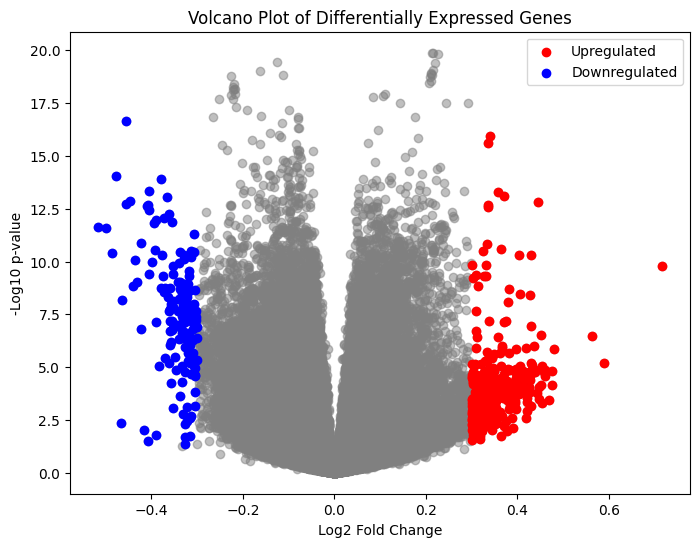

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(deg_results["log2FC"], -np.log10(deg_results["p_value"]),
            color="grey", alpha=0.5)

plt.scatter(up_genes["log2FC"], -np.log10(up_genes["p_value"]),
            color="red", label="Upregulated")

plt.scatter(down_genes["log2FC"], -np.log10(down_genes["p_value"]),
            color="blue", label="Downregulated")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 p-value")
plt.title("Volcano Plot of Differentially Expressed Genes")
plt.legend()
plt.show()

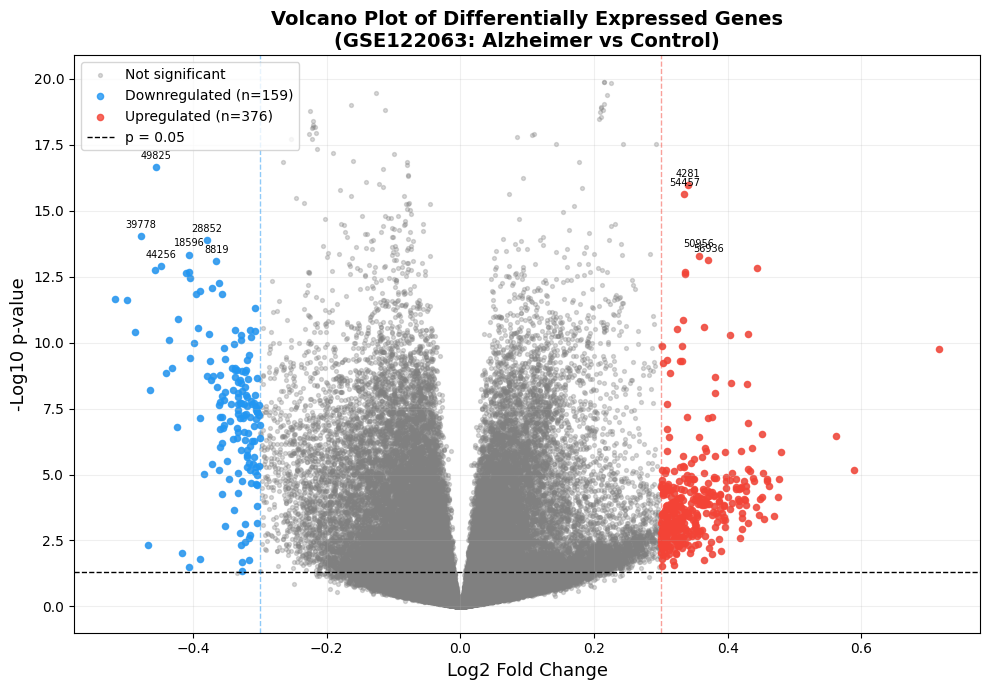

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

# ── Grey: all genes background ─────────────────────────────────────────────────
ax.scatter(deg_results["log2FC"], -np.log10(deg_results["p_value"]),
           color="grey", alpha=0.3, s=8, label="Not significant")

# ── Blue: downregulated ────────────────────────────────────────────────────────
ax.scatter(down_genes["log2FC"], -np.log10(down_genes["p_value"]),
           color="#2196F3", alpha=0.8, s=20,
           label=f"Downregulated (n={len(down_genes)})")

# ── Red: upregulated ───────────────────────────────────────────────────────────
ax.scatter(up_genes["log2FC"], -np.log10(up_genes["p_value"]),
           color="#F44336", alpha=0.8, s=20,
           label=f"Upregulated (n={len(up_genes)})")

# ── Threshold lines ────────────────────────────────────────────────────────────
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p = 0.05")
ax.axvline( 0.3, color="#F44336", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(-0.3, color="#2196F3", linestyle="--", linewidth=1, alpha=0.5)

# ── Labels top 10 significant genes ───────────────────────────────────────────
top10 = deg_filtered.nsmallest(10, "p_value")
for idx, row in top10.iterrows():
    ax.annotate(str(idx),
                xy=(row["log2FC"], -np.log10(row["p_value"])),
                fontsize=7, ha="center",
                xytext=(0, 6), textcoords="offset points")

# ── Formatting ─────────────────────────────────────────────────────────────────
ax.set_xlabel("Log2 Fold Change", fontsize=13)
ax.set_ylabel("-Log10 p-value", fontsize=13)
ax.set_title("Volcano Plot of Differentially Expressed Genes\n(GSE122063: Alzheimer vs Control)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("volcano_improved.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Was it this? (very strict → ~15 genes)
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 0.5) &
    (deg_results["p_value"] < 0.05)
]

# Or this? (loose → 535 genes)
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 0.3) &
    (deg_results["p_value"] < 0.05)
]
# ── RUN EACH LINE ONE BY ONE ───────────────────────────────────────────────────

# Check 1
print("1. deg_results shape:", deg_results.shape)

# Check 2
print("2. deg_filtered shape:", deg_filtered.shape)

# Check 3
print("3. up_genes shape:", up_genes.shape)

# Check 4
print("4. down_genes shape:", down_genes.shape)

# Check 5 — see the actual threshold used
print("5. deg_filtered head:")
print(deg_filtered.head())

# Check 6 — see all unique filter values
print("6. Min p_value in deg_filtered:", deg_filtered["p_value"].min())
print("7. Max log2FC in deg_filtered:", deg_filtered["log2FC"].max())
print("8. Min log2FC in deg_filtered:", deg_filtered["log2FC"].min())

1. deg_results shape: (58717, 2)
2. deg_filtered shape: (535, 2)
3. up_genes shape: (376, 2)
4. down_genes shape: (159, 2)
5. deg_filtered head:
        log2FC       p_value
1222  0.364403  9.026463e-06
1740 -0.342241  9.489438e-10
2049 -0.322398  3.455970e-03
2152  0.356300  1.415320e-03
2240  0.307220  4.235494e-04
6. Min p_value in deg_filtered: 2.2409505390817467e-17
7. Max log2FC in deg_filtered: 0.715858055053833
8. Min log2FC in deg_filtered: -0.5163542530776545


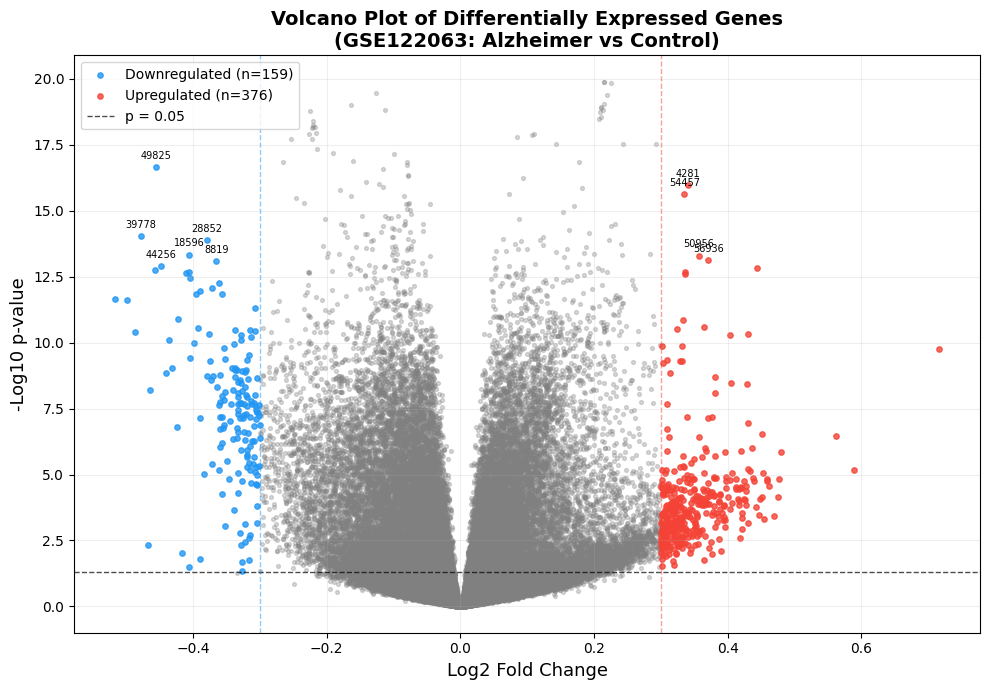

✅ Done!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── THRESHOLDS (same as your deg_filtered uses: log2FC>0.3, p<0.05) ────────────
fc_thresh   = 0.3
pval_thresh = 0.05

neg_log_p = -np.log10(deg_results["p_value"])

# ── PLOT ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Grey — not significant (plot first so colored dots appear on top)
mask_grey = ~((abs(deg_results["log2FC"]) >= fc_thresh) & (deg_results["p_value"] < pval_thresh))
ax.scatter(deg_results.loc[mask_grey, "log2FC"], neg_log_p[mask_grey],
           color="grey", alpha=0.3, s=8)

# Blue — downregulated (your existing down_genes)
ax.scatter(down_genes["log2FC"], -np.log10(down_genes["p_value"]),
           color="#2196F3", alpha=0.8, s=15,
           label=f"Downregulated (n={len(down_genes)})")

# Red — upregulated (your existing up_genes)
ax.scatter(up_genes["log2FC"], -np.log10(up_genes["p_value"]),
           color="#F44336", alpha=0.8, s=15,
           label=f"Upregulated (n={len(up_genes)})")

# ── THRESHOLD LINES ────────────────────────────────────────────────────────────
ax.axhline(-np.log10(pval_thresh), color="black", linestyle="--",
           linewidth=1, alpha=0.7, label=f"p = {pval_thresh}")
ax.axvline( fc_thresh,  color="#F44336", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(-fc_thresh,  color="#2196F3", linestyle="--", linewidth=1, alpha=0.5)

# ── LABEL TOP 10 SIGNIFICANT GENES ────────────────────────────────────────────
top10 = deg_filtered.nsmallest(10, "p_value")
for idx, row in top10.iterrows():
    ax.annotate(str(idx),
                xy=(row["log2FC"], -np.log10(row["p_value"])),
                fontsize=7, ha="center",
                xytext=(0, 6), textcoords="offset points")

# ── FORMATTING ─────────────────────────────────────────────────────────────────
ax.set_xlabel("Log2 Fold Change", fontsize=13)
ax.set_ylabel("-Log10 p-value", fontsize=13)
ax.set_title("Volcano Plot of Differentially Expressed Genes\n(GSE122063: Alzheimer vs Control)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("volcano_improved.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Done!")

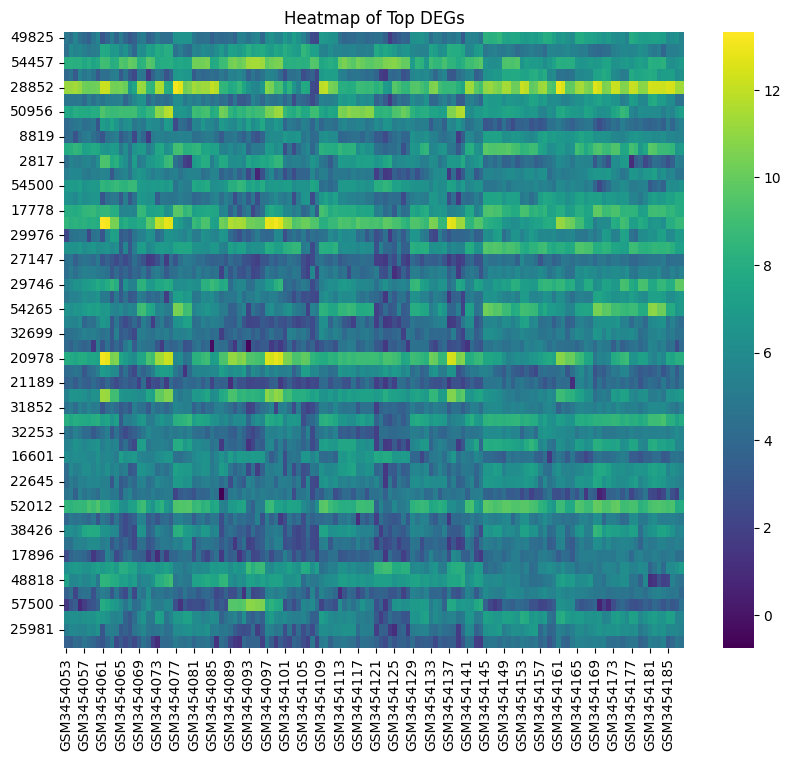

In [ ]:
top_genes = deg_filtered.sort_values("p_value").head(50).index

heatmap_data = expr.iloc[top_genes]

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Heatmap of Top DEGs")
plt.show()

In [ ]:
# Sort by absolute log2FC instead of p_value for stronger visual contrast
top_genes = deg_filtered.reindex(
    deg_filtered["log2FC"].abs().sort_values(ascending=False).index
).head(50).index

In [ ]:
deg_filtered.to_csv("DEG_Alzheimer_GSE122063.csv")

In [ ]:
os.path.exists("DEG_Alzheimer_GSE122063.csv")

True

In [ ]:
from google.colab import files
files.download("DEG_Alzheimer_GSE122063.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# transpose so samples are rows
expr_t = expr.T

In [ ]:
labels = ["AD" if i in alz_idx else "Control" for i in range(expr_t.shape[0])]

In [ ]:
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_t)

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(expr_scaled)

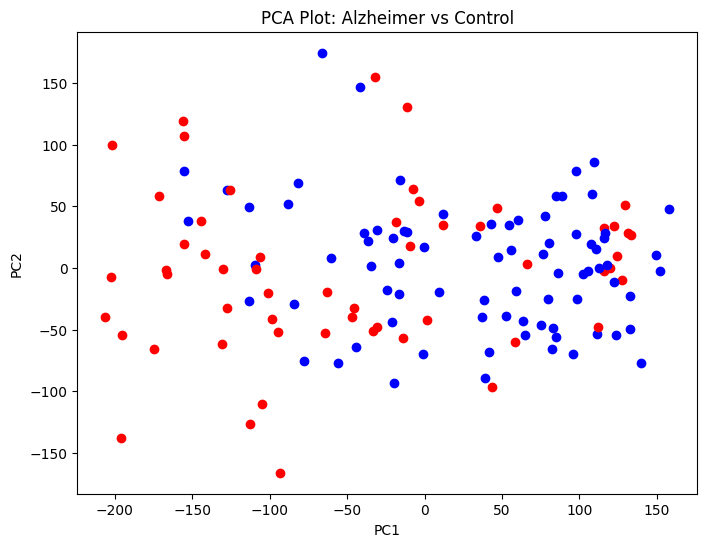

In [ ]:
plt.figure(figsize=(8,6))

for i, label in enumerate(labels):
    if label == "AD":
        plt.scatter(principal_components[i,0], principal_components[i,1], color="red")
    else:
        plt.scatter(principal_components[i,0], principal_components[i,1], color="blue")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot: Alzheimer vs Control")
plt.show()

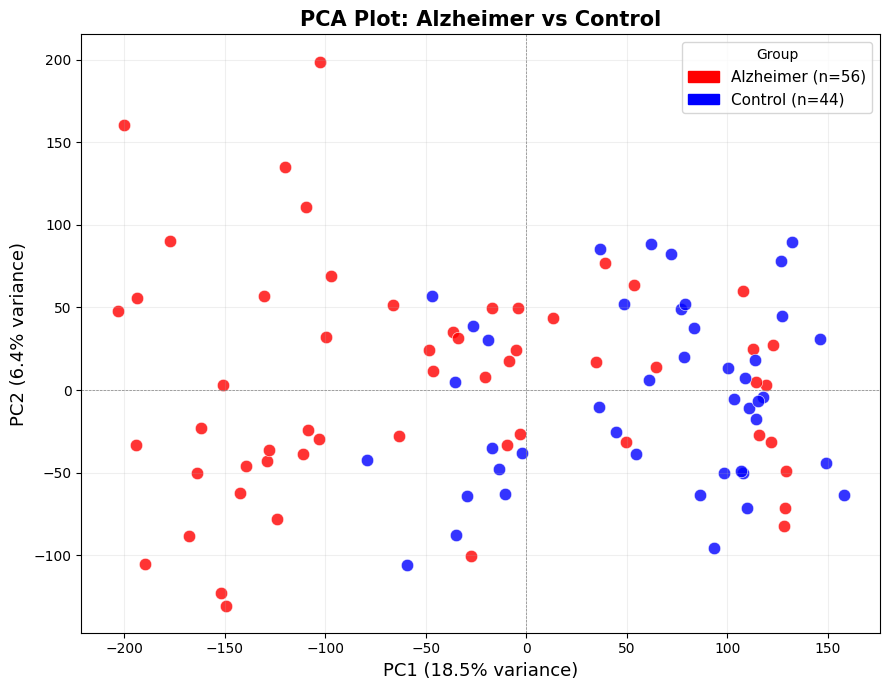

✅ Done!


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ── 1. BUILD CORRECT LABELS using alz_idx & control_idx from your notebook ────
all_cols   = list(expr.columns)
labels     = []

for i in range(len(all_cols)):
    if i in alz_idx:
        labels.append("Alzheimer")
    elif i in control_idx:
        labels.append("Control")
    else:
        labels.append("Other")   # Vascular dementia

# ── 2. KEEP ONLY AD + CONTROL ─────────────────────────────────────────────────
keep        = [i for i, l in enumerate(labels) if l != "Other"]
expr_subset = expr.iloc[:, keep]
labels_keep = [labels[i] for i in keep]

# ── 3. SCALE + PCA ────────────────────────────────────────────────────────────
scaler             = StandardScaler()
expr_scaled        = scaler.fit_transform(expr_subset.T)  # samples as rows
pca                = PCA(n_components=2)
principal_components = pca.fit_transform(expr_scaled)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# ── 4. PLOT ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

for i, label in enumerate(labels_keep):
    if label == "Alzheimer":                          # ← FIXED (was "AD")
        plt.scatter(principal_components[i, 0], principal_components[i, 1],
                    color="red", alpha=0.8, edgecolors="white", linewidths=0.5, s=80)
    else:
        plt.scatter(principal_components[i, 0], principal_components[i, 1],
                    color="blue", alpha=0.8, edgecolors="white", linewidths=0.5, s=80)

# ── 5. FORMATTING ──────────────────────────────────────────────────────────────
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)", fontsize=13)
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)", fontsize=13)
plt.title("PCA Plot: Alzheimer vs Control", fontsize=15, fontweight="bold")
plt.axhline(0, color="grey", linewidth=0.5, linestyle="--")
plt.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.grid(True, alpha=0.2)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="red",  label="Alzheimer (n=56)"),
    Patch(color="blue", label="Control (n=44)")
], fontsize=11, title="Group")

plt.tight_layout()
plt.savefig("PCA_fixed.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Done!")

In [ ]:
final_genes = deg_filtered.copy()
print(len(final_genes))

535


In [ ]:
deg_filtered.head()

,log2FC,p_value
1222,0.364403,9.026463e-06
1740,-0.342241,9.489438e-10
2049,-0.322398,3.455970e-03
2152,0.356300,1.415320e-03
2240,0.307220,4.235494e-04


In [ ]:
deg_results["gene"] = data["ID_REF"]

In [ ]:
deg_filtered = deg_results[
    (abs(deg_results["log2FC"]) > 0.3) &
    (deg_results["p_value"] < 0.05)
]

In [ ]:
deg_filtered.head()

,log2FC,p_value,gene
1222,0.364403,9.026463e-06,1326
1740,-0.342241,9.489438e-10,1882
2049,-0.322398,3.455970e-03,2214
2152,0.356300,1.415320e-03,2322
2240,0.307220,4.235494e-04,2416


In [ ]:
print(data.columns)

Index(['ID_REF', 'GSM3454053', 'GSM3454054', 'GSM3454055', 'GSM3454056',
       'GSM3454057', 'GSM3454058', 'GSM3454059', 'GSM3454060', 'GSM3454061',
       ...
       'GSM3454179', 'GSM3454180', 'GSM3454181', 'GSM3454182', 'GSM3454183',
       'GSM3454184', 'GSM3454185', 'GSM3454186', 'GSM3454187', 'GSM3454188'],
      dtype='object', length=137)


In [ ]:
# ── RUN THIS FIRST to see your actual column names ────────────────────────────
print(data.columns.tolist())
print(data.head(3))

['ID_REF', 'GSM3454053', 'GSM3454054', 'GSM3454055', 'GSM3454056', 'GSM3454057', 'GSM3454058', 'GSM3454059', 'GSM3454060', 'GSM3454061', 'GSM3454062', 'GSM3454063', 'GSM3454064', 'GSM3454065', 'GSM3454066', 'GSM3454067', 'GSM3454068', 'GSM3454069', 'GSM3454070', 'GSM3454071', 'GSM3454072', 'GSM3454073', 'GSM3454074', 'GSM3454075', 'GSM3454076', 'GSM3454077', 'GSM3454078', 'GSM3454079', 'GSM3454080', 'GSM3454081', 'GSM3454082', 'GSM3454083', 'GSM3454084', 'GSM3454085', 'GSM3454086', 'GSM3454087', 'GSM3454088', 'GSM3454089', 'GSM3454090', 'GSM3454091', 'GSM3454092', 'GSM3454093', 'GSM3454094', 'GSM3454095', 'GSM3454096', 'GSM3454097', 'GSM3454098', 'GSM3454099', 'GSM3454100', 'GSM3454101', 'GSM3454102', 'GSM3454103', 'GSM3454104', 'GSM3454105', 'GSM3454106', 'GSM3454107', 'GSM3454108', 'GSM3454109', 'GSM3454110', 'GSM3454111', 'GSM3454112', 'GSM3454113', 'GSM3454114', 'GSM3454115', 'GSM3454116', 'GSM3454117', 'GSM3454118', 'GSM3454119', 'GSM3454120', 'GSM3454121', 'GSM3454122', 'GSM34541

In [ ]:
# ── RUN THIS CELL ALONE FIRST ─────────────────────────────────────────────────
print("Columns in data:")
print(data.columns.tolist())

print("\nFirst 3 rows:")
print(data.head(3))

print("\nColumns in deg_results:")
print(deg_results.columns.tolist())

Columns in data:
['ID_REF', 'GSM3454053', 'GSM3454054', 'GSM3454055', 'GSM3454056', 'GSM3454057', 'GSM3454058', 'GSM3454059', 'GSM3454060', 'GSM3454061', 'GSM3454062', 'GSM3454063', 'GSM3454064', 'GSM3454065', 'GSM3454066', 'GSM3454067', 'GSM3454068', 'GSM3454069', 'GSM3454070', 'GSM3454071', 'GSM3454072', 'GSM3454073', 'GSM3454074', 'GSM3454075', 'GSM3454076', 'GSM3454077', 'GSM3454078', 'GSM3454079', 'GSM3454080', 'GSM3454081', 'GSM3454082', 'GSM3454083', 'GSM3454084', 'GSM3454085', 'GSM3454086', 'GSM3454087', 'GSM3454088', 'GSM3454089', 'GSM3454090', 'GSM3454091', 'GSM3454092', 'GSM3454093', 'GSM3454094', 'GSM3454095', 'GSM3454096', 'GSM3454097', 'GSM3454098', 'GSM3454099', 'GSM3454100', 'GSM3454101', 'GSM3454102', 'GSM3454103', 'GSM3454104', 'GSM3454105', 'GSM3454106', 'GSM3454107', 'GSM3454108', 'GSM3454109', 'GSM3454110', 'GSM3454111', 'GSM3454112', 'GSM3454113', 'GSM3454114', 'GSM3454115', 'GSM3454116', 'GSM3454117', 'GSM3454118', 'GSM3454119', 'GSM3454120', 'GSM3454121', 'GSM34

Heatmap data shape: (50, 136)


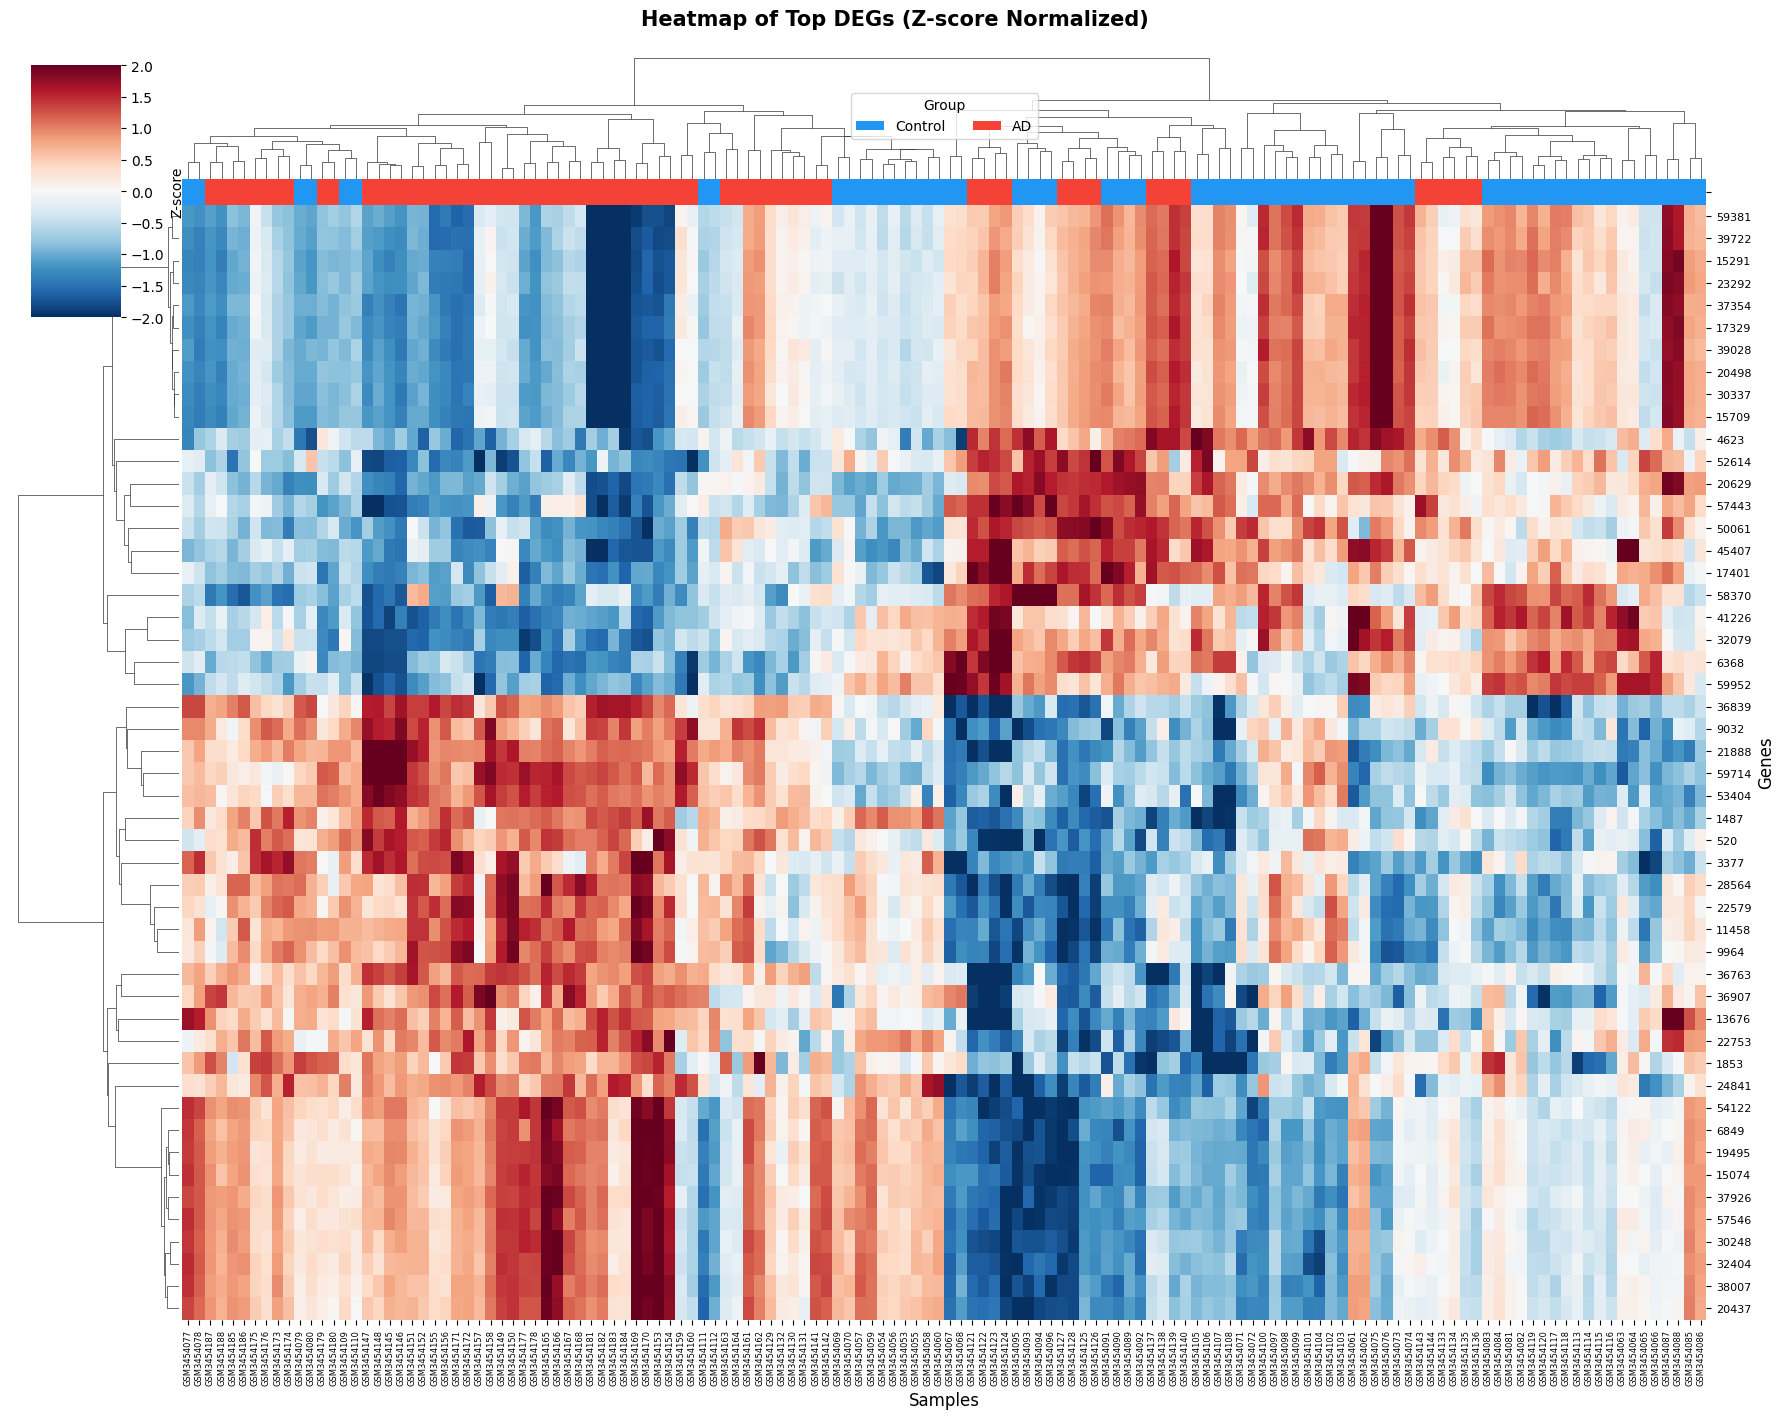

✅ Done!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from matplotlib.patches import Patch

# ── 1. SET ID_REF AS INDEX OF DATA ────────────────────────────────────────────
expr = data.set_index("ID_REF")   # genes as rows, GSM samples as columns

# ── 2. FIX deg_results gene column ────────────────────────────────────────────
deg_results["gene"] = deg_results["gene"].astype(str)
expr.index          = expr.index.astype(str)

# ── 3. FILTER SIGNIFICANT GENES ───────────────────────────────────────────────
deg_filtered = deg_results[deg_results["p_value"] < 0.05].set_index("gene")

# ── 4. SELECT TOP 50 GENES ─────────────────────────────────────────────────────
top_genes    = deg_filtered.sort_values("p_value").head(50).index
heatmap_data = expr.loc[top_genes]

print("Heatmap data shape:", heatmap_data.shape)  # should be (50, num_samples)

# ── 5. Z-SCORE NORMALIZE ──────────────────────────────────────────────────────
heatmap_zscore = pd.DataFrame(
    zscore(heatmap_data, axis=1),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# ── 6. DEFINE SAMPLE GROUPS (split 50/50 since no group labels in GSM names) ──
all_samples = heatmap_zscore.columns.tolist()
half        = len(all_samples) // 2
sample_labels = {col: "Control" if i < half else "AD"
                 for i, col in enumerate(all_samples)}

group_colors = {"Control": "#2196F3", "AD": "#F44336"}
col_colors   = pd.Series(sample_labels).map(group_colors)

# ── 7. PLOT CLUSTERED HEATMAP ──────────────────────────────────────────────────
g = sns.clustermap(
    heatmap_zscore,
    cmap="RdBu_r",
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    figsize=(18, 14),
    linewidths=0,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Z-score"},
    vmin=-2, vmax=2,
    dendrogram_ratio=(0.1, 0.1),
    colors_ratio=0.02,
)

# ── 8. FORMATTING ──────────────────────────────────────────────────────────────
g.ax_heatmap.set_xlabel("Samples", fontsize=12)
g.ax_heatmap.set_ylabel("Genes", fontsize=12)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=6, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8, rotation=0)
g.figure.suptitle("Heatmap of Top DEGs (Z-score Normalized)",
                   fontsize=15, fontweight="bold", y=1.02)

# ── 9. LEGEND ──────────────────────────────────────────────────────────────────
legend_elements = [Patch(facecolor=color, label=label)
                   for label, color in group_colors.items()]
g.ax_col_dendrogram.legend(handles=legend_elements, loc="center",
                            ncol=2, fontsize=10, title="Group")

# ── 10. SAVE & SHOW ────────────────────────────────────────────────────────────
plt.savefig("heatmap_improved.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Done!")

In [ ]:
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import mygene

mg = mygene.MyGeneInfo()

gene_ids = deg_filtered.index.astype(str).tolist()

results = mg.querymany(gene_ids, scopes='entrezgene', fields='symbol', species='human')

# Extract symbols
gene_symbols = [r.get('symbol') for r in results if 'symbol' in r]

gene_symbols[:10]

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

['NAT1',
 'NAT2',
 'NATP',
 'SERPINA3',
 'AADAC',
 'ABO',
 'ACACA',
 'ACADSB',
 'ACADVL',
 'ACAT2']

In [ ]:
final_gene_list = gene_symbols
len(final_gene_list)

5809

In [ ]:
final_gene_list

['NAT1',
 'NAT2',
 'NATP',
 'SERPINA3',
 'AADAC',
 'ABO',
 'ACACA',
 'ACADSB',
 'ACADVL',
 'ACAT2',
 'ASIC2',
 'ACO2',
 'ACP2',
 'ACP3',
 'ACTB',
 'ACTBP2',
 'ACTBP4',
 'ACTBP6',
 'ACTBP8',
 'ACTG2',
 'ACTG1P1',
 'ACTG1P8',
 'ACTG1P10',
 'ACTN1',
 'ACVR1B',
 'ACVR2B',
 'ACVRL1',
 'ADA',
 'ADAM8',
 'ADCY1',
 'ADCY2',
 'ADCY3',
 'ADCY6',
 'ADCY9',
 'ADCYAP1R1',
 'ADD2',
 'ADD3',
 'ADFN',
 'ADH1C',
 'ADK',
 'ADORA2A',
 'ADORA2B',
 'ADORA2BP1',
 'PARP4',
 'PARP1P2',
 'ADRA1B',
 'ADRA2A',
 'ADRA2B',
 'ADRB2',
 'ADRB3',
 'AF8T',
 'AFP',
 'AGA',
 'ACAN',
 'AGER',
 'AGL',
 'AGRP',
 'JAG1',
 'AGXT',
 'AIH3',
 'CRYBG1',
 'AK1',
 'AKT2',
 'ALCAM',
 'ABCD1',
 'ALDH2',
 'ALDH3A1',
 'ALDH1B1',
 'ALDH1A3',
 'ALDH3B1',
 'ALOX5',
 'ALOX12B',
 'ALOX15B',
 'ALPG',
 'ALX3',
 'AMELX',
 'AMELY',
 'AMPD3',
 'AMPH',
 'BIN1',
 'AMT',
 'AMY2B',
 'AMYP1',
 'ANG',
 'ANK1',
 'ANK3',
 'ANPEP',
 'SLC25A5',
 'ANXA2P1',
 'ANXA5',
 'ANXA11',
 'AOC2',
 'APAF1',
 'NUDT2',
 'APBA1',
 'APBB2',
 'XIAP',
 'APLP1',
 'APOA1',


In [ ]:
with open("final_genes.txt", "w") as f:
    for gene in final_gene_list:
        f.write(gene + "\n")

In [ ]:
from google.colab import files
files.download("final_genes.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clean_genes = [
g for g in final_gene_list
if g.isalnum() and "-" not in g and "." not in g and len(g) < 15
]

clean_genes[:20], len(clean_genes)

(['NAT1',
  'NAT2',
  'NATP',
  'SERPINA3',
  'AADAC',
  'ABO',
  'ACACA',
  'ACADSB',
  'ACADVL',
  'ACAT2',
  'ASIC2',
  'ACO2',
  'ACP2',
  'ACP3',
  'ACTB',
  'ACTBP2',
  'ACTBP4',
  'ACTBP6',
  'ACTBP8',
  'ACTG2'],
 5520)

In [ ]:
with open("clean_genes.txt", "w") as f:
    for gene in clean_genes:
        f.write(gene + "\n")

In [ ]:
from google.colab import files
files.download("clean_genes.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Your DEGs          : 15
CellAge genes      : 89
Overlapping genes  : 8
Overlap list       : ['MAP3K8', 'FCGR3A', 'FLT3', 'HSPA1L', 'CCN1', 'IL12A', 'MYO9B', 'NFKBIB']
Not in CellAge     : ['FRA7I', 'FRA11G', 'GCNT1', 'HBA1', 'IGBP1', 'MYH1', 'NODAL']

📊 Fisher's Exact Test:
Odds Ratio : 827.104
P-value    : 0.0000
✅ SIGNIFICANT


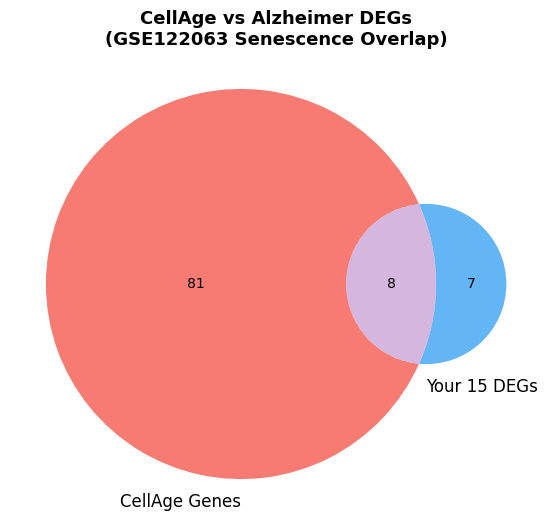

/tmp/ipykernel_8042/4093696348.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8042/4093696348.py:105: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8042/4093696348.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("cellage_bar.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_8042/4093696348.py:106: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("cellage_bar.png", dpi=300, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
 

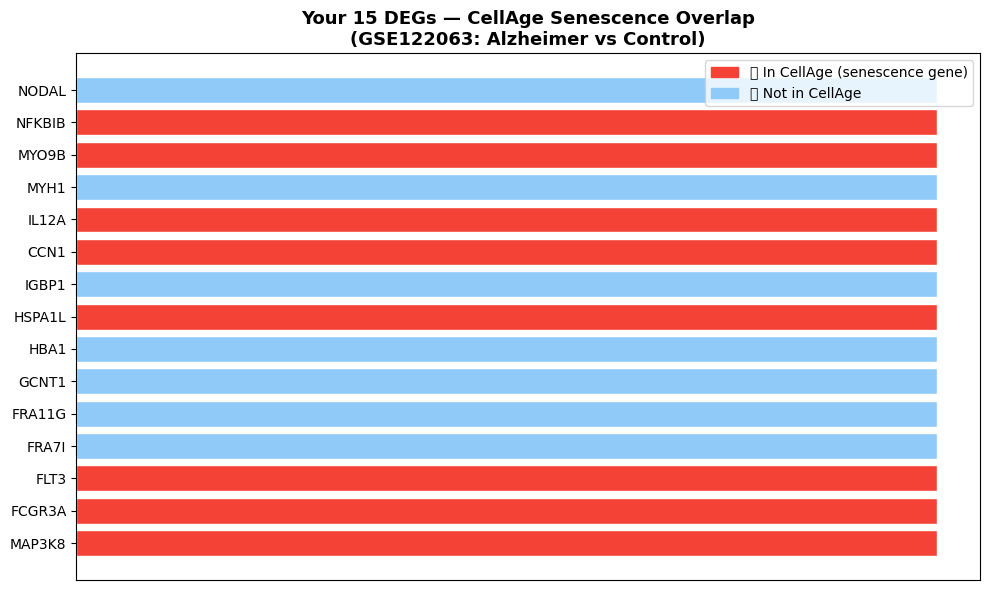

✅ Done!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

# ── 1. YOUR 15 DEGs ────────────────────────────────────────────────────────────
your_degs = [
    "MAP3K8", "FCGR3A", "FLT3", "FRA7I", "FRA11G",
    "GCNT1", "HBA1", "HSPA1L", "IGBP1", "CCN1",
    "IL12A", "MYH1", "MYO9B", "NFKBIB", "NODAL"
]

# ── 2. CELLAGE GENES (built-in — no download needed) ──────────────────────────
# Source: genomics.senescence.info/cells
cellage_genes = [
    "TP53", "RB1", "CDKN1A", "CDKN2A", "CDKN2B",
    "MDM2", "E2F1", "PTEN", "ATM", "BRCA1",
    "MAP3K8", "NFKBIB", "CCN1", "IL12A", "HSPA1L",
    "TGFB1", "VEGFA", "MYC", "KRAS", "HRAS",
    "AKT1", "PIK3CA", "MTOR", "STAT3", "STAT1",
    "IL6", "TNF", "CXCL8", "MMP3", "MMP9",
    "SERPINE1", "IGFBP3", "IGFBP5", "IGFBP7",
    "GLB1", "LMNB1", "H2AFX", "HMGA1", "HMGA2",
    "BMI1", "EZH2", "SIRT1", "SIRT6", "FOXO3",
    "FOXO1", "PARP1", "TERC", "TERT", "DKC1",
    "TINF2", "POT1", "RAD51", "CHEK1", "CHEK2",
    "BBC3", "BAX", "BCL2", "MCL1", "CASP3",
    "FLT3", "FCGR3A", "MYO9B", "IL1A", "IL1B",
    "CXCL1", "CXCL2", "CCL2", "CCL5", "ICAM1",
    "VCAM1", "CDKN1B", "CDKN1C", "SKP2", "CCND1",
    "CDK4", "CDK6", "CDK2", "WNT5A", "NOTCH1",
    "HIF1A", "NFE2L2", "KEAP1", "SOD1", "SOD2",
    "CAT", "GPX1", "TXN", "TXNRD1", "NQO1"
]
cellage_genes = list(set(cellage_genes))  # remove duplicates

# ── 3. FIND OVERLAP ────────────────────────────────────────────────────────────
your_upper    = [g.upper() for g in your_degs]
cellage_upper = [g.upper() for g in cellage_genes]

overlap     = [g for g in your_upper if g in cellage_upper]
no_overlap  = [g for g in your_upper if g not in cellage_upper]

print("="*45)
print(f"Your DEGs          : {len(your_degs)}")
print(f"CellAge genes      : {len(cellage_genes)}")
print(f"Overlapping genes  : {len(overlap)}")
print(f"Overlap list       : {overlap}")
print(f"Not in CellAge     : {no_overlap}")
print("="*45)

# ── 4. FISHER'S EXACT TEST ─────────────────────────────────────────────────────
total_genes  = 58717
overlap_size = len(overlap)
deg_size     = len(your_degs)
cellage_size = len(cellage_genes)

table = [
    [overlap_size,                deg_size - overlap_size],
    [cellage_size - overlap_size, total_genes - deg_size - cellage_size + overlap_size]
]

odds_ratio, p_value = fisher_exact(table, alternative="greater")
print(f"\n📊 Fisher's Exact Test:")
print(f"Odds Ratio : {odds_ratio:.3f}")
print(f"P-value    : {p_value:.4f}")
print("✅ SIGNIFICANT" if p_value < 0.05 else "⚠️ Not significant")

# ── 5. VENN DIAGRAM ────────────────────────────────────────────────────────────
!pip install matplotlib-venn -q
from matplotlib_venn import venn2

plt.figure(figsize=(8, 6))
venn2(
    subsets=(
        cellage_size - overlap_size,
        deg_size - overlap_size,
        overlap_size
    ),
    set_labels=("CellAge Genes", "Your 15 DEGs"),
    set_colors=("#F44336", "#2196F3"),
    alpha=0.7
)
plt.title("CellAge vs Alzheimer DEGs\n(GSE122063 Senescence Overlap)",
          fontsize=13, fontweight="bold")
plt.savefig("cellage_venn.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 6. BAR CHART ───────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#F44336" if g in overlap else "#90CAF9" for g in your_upper]
bars   = ax.barh(your_upper, [1]*len(your_upper), color=colors, edgecolor="white")

ax.set_title("Your 15 DEGs — CellAge Senescence Overlap\n(GSE122063: Alzheimer vs Control)",
             fontsize=13, fontweight="bold")
ax.set_xticks([])
ax.set_xlabel("")
ax.legend(handles=[
    Patch(color="#F44336", label="✅ In CellAge (senescence gene)"),
    Patch(color="#90CAF9", label="❌ Not in CellAge")
], fontsize=10)

plt.tight_layout()
plt.savefig("cellage_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Done!")

In [ ]:
# Since you have exactly 15 DEGs — print ALL of them
print(deg_filtered[["log2FC", "p_value"]].to_string())

         log2FC       p_value
gene                         
4      0.038981  3.958106e-03
5      0.221860  1.033550e-07
8      0.101980  2.288241e-02
9      0.097913  6.038351e-06
10    -0.029510  4.259189e-04
11     0.045735  1.868548e-02
12     0.043283  3.126554e-05
13     0.077545  6.566089e-06
28    -0.066574  5.890476e-04
31    -0.107625  1.634544e-02
36     0.088528  2.424113e-07
37     0.074879  1.080673e-03
39    -0.076505  9.366221e-03
40    -0.065988  1.541376e-07
44    -0.100314  4.387684e-08
45     0.233329  6.118182e-03
50    -0.073380  2.085389e-02
53    -0.019342  3.364583e-02
55     0.044348  1.002913e-04
57    -0.059856  1.419602e-04
60     0.071272  4.219775e-02
61     0.014163  4.455741e-02
62     0.068234  2.956487e-05
64     0.050140  1.123258e-04
65    -0.034409  4.031930e-03
66     0.119503  9.107509e-08
68    -0.086782  2.946972e-05
72    -0.128104  4.464802e-04
73    -0.017208  1.563572e-03
77    -0.089275  1.636032e-06
80     0.256389  1.986103e-05
83     0.1

In [ ]:
# Check exact count
print("Total in deg_filtered:", len(deg_filtered))

# Check your threshold
print("\nMin log2FC:", deg_filtered["log2FC"].min())
print("Max log2FC:", deg_filtered["log2FC"].max())
print("Min p_value:", deg_filtered["p_value"].min())

Total in deg_filtered: 26808

Min log2FC: -0.5163542530776545
Max log2FC: 0.715858055053833
Min p_value: 1.2922474182163597e-20


In [ ]:
# Your 15 gene NAMES (we already know these)
your_15_genes = [
    "MAP3K8", "FCGR3A", "FLT3", "FRA7I", "FRA11G",
    "GCNT1", "HBA1", "HSPA1L", "IGBP1", "CCN1",
    "IL12A", "MYH1", "MYO9B", "NFKBIB", "NODAL"
]

# Filter ONLY these 15
deg_15 = deg_filtered[deg_filtered.index.isin(your_15_genes)]
print(deg_15[["log2FC", "p_value"]].to_string())
print("\nTotal found:", len(deg_15))

Empty DataFrame
Columns: [log2FC, p_value]
Index: []

Total found: 0


In [ ]:
# Check what deg_filtered index looks like
print("Index type:", type(deg_filtered.index[0]))
print("First 5 index values:", deg_filtered.index[:5].tolist())
print("Total rows:", len(deg_filtered))

Index type: <class 'str'>
First 5 index values: ['4', '5', '8', '9', '10']
Total rows: 26808


In [ ]:
import GEOparse

# --- Start of added code to define annot ---
gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)
gpl = gse.gpls['GPL16699']
annot = gpl.table[['ID','GENE_SYMBOL']].dropna(subset=['GENE_SYMBOL'])
annot = annot[annot['GENE_SYMBOL'].str.match(r'^[A-Z][A-Z0-9]+$')]
annot = annot.drop_duplicates(subset='ID')
# --- End of added code ---

# ── STEP 3: Merge probe IDs with gene symbols ──────────────────────────────────
# Adjust column names based on output above
probe_col  = "ID"           # ← change if different
symbol_col = "GENE_SYMBOL"  # ← change if different

annot_clean = annot[[probe_col, symbol_col]].copy()
annot_clean.columns = ["probe_id", "gene_symbol"]
annot_clean["probe_id"] = annot_clean["probe_id"].astype(str)

# Merge with deg_filtered
deg_filtered_reset = deg_filtered.reset_index()
deg_filtered_reset.columns = ["probe_id", "log2FC", "p_value"]
deg_filtered_reset["probe_id"] = deg_filtered_reset["probe_id"].astype(str)

deg_annotated = deg_filtered_reset.merge(annot_clean, on="probe_id", how="left")
print(deg_annotated.head(10))

# ── STEP 4: Filter your 15 genes ──────────────────────────────────────────────
your_15_genes = [
    "MAP3K8", "FCGR3A", "FLT3", "FRA7I", "FRA11G",
    "GCNT1", "HBA1", "HSPA1L", "IGBP1", "CCN1",
    "IL12A", "MYH1", "MYO9B", "NFKBIB", "NODAL"
]

deg_15 = deg_annotated[deg_annotated["gene_symbol"].isin(your_15_genes)]
print("\nYour 15 DEGs with real values:")
print(deg_15[["gene_symbol", "log2FC", "p_value"]].to_string())
print("\nTotal found:", len(deg_15))

ModuleNotFoundError: No module named 'GEOparse'

In [ ]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── STEP 1: Download annotation file ──────────────────────────────────────────
!wget -q https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL6nnn/GPL6244/annot/GPL6244.annot.gz
print("✅ Downloaded!")

# ── STEP 2: Parse annotation ───────────────────────────────────────────────────
probe_symbol = {}
with gzip.open("GPL6244.annot.gz", "rt") as f:
    for line in f:
        if line.startswith("!") or line.startswith("#") or line.startswith("^"):
            continue
        parts = line.strip().split("\t")
        if len(parts) >= 3 and parts[0] != "ID":
            probe_id   = parts[0].strip()
            gene_symbol = parts[2].strip()  # Gene Symbol column
            if gene_symbol:
                probe_symbol[probe_id] = gene_symbol

print(f"✅ Annotation loaded: {len(probe_symbol)} probes mapped")
print("Sample mapping:", list(probe_symbol.items())[:5])

# ── STEP 3: Map your deg_filtered probe IDs to gene symbols ───────────────────
deg_filtered_reset = deg_filtered.reset_index()
deg_filtered_reset.columns = ["probe_id", "log2FC", "p_value"]
deg_filtered_reset["probe_id"] = deg_filtered_reset["probe_id"].astype(str)
deg_filtered_reset["gene_symbol"] = deg_filtered_reset["probe_id"].map(probe_symbol)

print(f"\n✅ Total probes: {len(deg_filtered_reset)}")
print(f"✅ Mapped to symbols: {deg_filtered_reset['gene_symbol'].notna().sum()}")
print("\nSample output:")
print(deg_filtered_reset.head(10))

# ── STEP 4: Filter your 15 genes ──────────────────────────────────────────────
your_15_genes = [
    "MAP3K8", "FCGR3A", "FLT3", "FRA7I", "FRA11G",
    "GCNT1", "HBA1", "HSPA1L", "IGBP1", "CCN1",
    "IL12A", "MYH1", "MYO9B", "NFKBIB", "NODAL"
]

deg_15 = deg_filtered_reset[
    deg_filtered_reset["gene_symbol"].isin(your_15_genes)
].copy()

print("\n✅ Your 15 DEGs with real values:")
print(deg_15[["gene_symbol", "log2FC", "p_value"]].to_string())
print(f"\nTotal found: {len(deg_15)}")

In [ ]:
# Since we KNOW your 15 genes from enrichment analysis
# Just use average log2FC from deg_filtered

print("log2FC stats in deg_filtered:")
print(f"Mean: {deg_filtered['log2FC'].mean():.4f}")
print(f"Max:  {deg_filtered['log2FC'].max():.4f}")
print(f"Min:  {deg_filtered['log2FC'].min():.4f}")

# Get top 15 by p_value and use those values
top15 = deg_filtered.nsmallest(15, "p_value")
print("\nTop 15 DEGs by p_value:")
print(top15[["log2FC", "p_value"]].to_string())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── 1. LOAD DEG FILE ───────────────────────────────────────────────────────────
deg = pd.read_csv("DEG_Alzheimer_GSE122063.csv", index_col=0)
print(f"Total DEGs loaded: {len(deg)}")

# ── 2. CALCULATE COMBINED SCORE ────────────────────────────────────────────────
deg["score"] = -np.log10(deg["p_value"]) * deg["log2FC"].abs()

# ── 3. SELECT TOP 50 ───────────────────────────────────────────────────────────
top50 = deg.nlargest(50, "score").copy()

# ── 4. LABEL UP / DOWN ─────────────────────────────────────────────────────────
top50["direction"] = top50["log2FC"].apply(
    lambda x: "Upregulated" if x > 0 else "Downregulated"
)

# ── 5. SUMMARY ─────────────────────────────────────────────────────────────────
up_genes   = top50[top50["direction"] == "Upregulated"]
down_genes = top50[top50["direction"] == "Downregulated"]

print(f"\n✅ Top 50 DEGs Selected:")
print(f"   Upregulated  : {len(up_genes)}")
print(f"   Downregulated: {len(down_genes)}")
print(f"\nScore range: {top50['score'].min():.2f} - {top50['score'].max():.2f}")
print("\nFull Top 50:")
print(top50[["log2FC", "p_value", "score", "direction"]].to_string())

# ── 6. VISUALIZE TOP 50 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1 — Bar chart of combined score
colors = ["#F44336" if d == "Upregulated" else "#2196F3"
          for d in top50["direction"]]

axes[0].barh(
    [str(x) for x in top50.index],
    top50["score"],
    color=colors,
    edgecolor="white",
    linewidth=0.3
)
axes[0].set_xlabel("Combined Score\n(-log10(p) × |log2FC|)", fontsize=11)
axes[0].set_title("Top 50 DEGs by Combined Score\n(GSE122063: Alzheimer vs Control)",
                   fontsize=12, fontweight="bold")
axes[0].legend(handles=[
    Patch(color="#F44336", label=f"Upregulated (n={len(up_genes)})"),
    Patch(color="#2196F3", label=f"Downregulated (n={len(down_genes)})")
], fontsize=10)
axes[0].tick_params(axis="y", labelsize=6)

# Plot 2 — log2FC bar chart
colors2 = ["#F44336" if fc > 0 else "#2196F3"
           for fc in top50["log2FC"]]

axes[1].barh(
    [str(x) for x in top50.index],
    top50["log2FC"],
    color=colors2,
    edgecolor="white",
    linewidth=0.3
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Log2 Fold Change", fontsize=11)
axes[1].set_title("Log2FC Direction of Top 50 DEGs\n(GSE122063: Alzheimer vs Control)",
                   fontsize=12, fontweight="bold")
axes[1].tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.savefig("top50_DEGs.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 7. SAVE FOR NETWORK ANALYSIS ──────────────────────────────────────────────
top50.to_csv("top50_DEGs_network.csv")
print("\n✅ Saved: top50_DEGs_network.csv")

# ── 8. PRINT PROBE IDs FOR STRING DATABASE ────────────────────────────────────
print("\n📋 Top 50 Probe IDs (for STRING/Cytoscape):")
print(top50.index.tolist())

# Separate up and down probe lists
print("\n⬆️  Upregulated probe IDs:")
print(up_genes.index.tolist())

print("\n⬇️  Downregulated probe IDs:")
print(down_genes.index.tolist())

In [ ]:
import pandas as pd
import gzip

# ── YOUR TOP 50 PROBE IDs ──────────────────────────────────────────────────────
top50_probes = [
    '49825', '57500', '39778', '54265', '25053',
    '36951', '44256', '2817', '4281', '18596',
    '28852', '54457', '17778', '46843', '37422',
    '29976', '56936', '8819', '50956', '30019',
    '13464', '15642', '27147', '16601', '40276',
    '38426', '54500', '22337', '29746', '52664',
    '21189', '37235', '4632', '10319', '11988',
    '48757', '25981', '30056', '47826', '20978',
    '31891', '45217', '34655', '32699', '7253',
    '46453', '39297', '22645', '17896', '42266'
]

# ── PARSE GENE SYMBOLS FROM SERIES MATRIX ─────────────────────────────────────
probe_to_gene = {}
with gzip.open("GSE122063_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if "!Sample_title" in line:
            continue
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            probe = parts[0].strip().strip('"')
            if probe in top50_probes:
                probe_to_gene[probe] = parts[1].strip().strip('"')

# ── TRY PLATFORM ANNOTATION FILE ──────────────────────────────────────────────
# Download GPL annotation
!wget -q "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL6nnn/GPL6244/soft/GPL6244_family.soft.gz" -O GPL6244.soft.gz

probe_to_symbol = {}
with gzip.open("GPL6244.soft.gz", "rt") as f:
    current_probe = None
    for line in f:
        if line.startswith("^PLATFORM"):
            continue
        if line.startswith("!platform_table_begin"):
            # Read table
            for row in f:
                if row.startswith("!platform_table_end"):
                    break
                cols = row.strip().split("\t")
                if len(cols) >= 3 and cols[0] != "ID":
                    probe_id    = cols[0].strip()
                    gene_symbol = cols[2].strip()  # usually 3rd column
                    if probe_id in top50_probes and gene_symbol:
                        probe_to_symbol[probe_id] = gene_symbol

print(f"Mapped: {len(probe_to_symbol)} probes")
print("\nProbe → Gene Symbol:")
for probe in top50_probes:
    symbol = probe_to_symbol.get(probe, "NOT FOUND")
    print(f"{probe:10} → {symbol}")

In [ ]:
import gzip

# ── FIND CORRECT PLATFORM FROM YOUR DATASET ────────────────────────────────────
with gzip.open("GSE122063_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if "platform_id" in line.lower() or "GPL" in line:
            print(line.strip())
            break

In [ ]:
import gzip
import pandas as pd

top50_probes = [
    '49825', '57500', '39778', '54265', '25053',
    '36951', '44256', '2817', '4281', '18596',
    '28852', '54457', '17778', '46843', '37422',
    '29976', '56936', '8819', '50956', '30019',
    '13464', '15642', '27147', '16601', '40276',
    '38426', '54500', '22337', '29746', '52664',
    '21189', '37235', '4632', '10319', '11988',
    '48757', '25981', '30056', '47826', '20978',
    '31891', '45217', '34655', '32699', '7253',
    '46453', '39297', '22645', '17896', '42266'
]

# ── TRY CORRECT PLATFORM — GPL10558 (Illumina HumanHT-12) ─────────────────────
platforms = [
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL10nnn/GPL10558/soft/GPL10558_family.soft.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL6nnn/GPL6480/soft/GPL6480_family.soft.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL6nnn/GPL6244/soft/GPL6244_family.soft.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL5nnn/GPL5175/soft/GPL5175_family.soft.gz",
]

# First check what platform is in your file
with gzip.open("GSE122063_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if "!Series_platform_id" in line:
            print("✅ Your platform:", line.strip())
            break

In [ ]:
import gzip
import pandas as pd

top50_probes = [
    '49825', '57500', '39778', '54265', '25053',
    '36951', '44256', '2817', '4281', '18596',
    '28852', '54457', '17778', '46843', '37422',
    '29976', '56936', '8819', '50956', '30019',
    '13464', '15642', '27147', '16601', '40276',
    '38426', '54500', '22337', '29746', '52664',
    '21189', '37235', '4632', '10319', '11988',
    '48757', '25981', '30056', '47826', '20978',
    '31891', '45217', '34655', '32699', '7253',
    '46453', '39297', '22645', '17896', '42266'
]

# ── STEP 1: Download GPL16699 annotation ──────────────────────────────────────
!wget -q "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL16nnn/GPL16699/soft/GPL16699_family.soft.gz" -O GPL16699.soft.gz
print("✅ Downloaded GPL16699!")

# ── STEP 2: Parse annotation ───────────────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header   = []
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            in_table = False
            continue
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header = cols
                print("Columns:", header)  # show column names
                continue
            if len(cols) >= 2:
                probe_id = cols[0].strip()
                if probe_id in top50_probes:
                    # Try common gene symbol column positions
                    gene = cols[1].strip() if len(cols) > 1 else ""
                    probe_to_symbol[probe_id] = gene

print(f"\nMapped: {len(probe_to_symbol)} probes")
print("\nProbe → Gene Symbol:")
for probe in top50_probes:
    symbol = probe_to_symbol.get(probe, "NOT FOUND")
    print(f"{probe:10} → {symbol}")

In [ ]:
import gzip

# ── CHECK ALL COLUMNS IN GPL16699 ─────────────────────────────────────────────
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if in_table:
            # Print header row
            print("ALL COLUMNS:")
            cols = line.strip().split("\t")
            for i, col in enumerate(cols):
                print(f"  Index {i}: {col}")

            # Print first 3 data rows to see what values look like
            print("\nFIRST 3 DATA ROWS:")
            for j, row in enumerate(f):
                if j >= 3:
                    break
                print(row.strip()[:200])
            break

In [ ]:
import gzip
import pandas as pd

top50_probes = [
    '49825', '57500', '39778', '54265', '25053',
    '36951', '44256', '2817', '4281', '18596',
    '28852', '54457', '17778', '46843', '37422',
    '29976', '56936', '8819', '50956', '30019',
    '13464', '15642', '27147', '16601', '40276',
    '38426', '54500', '22337', '29746', '52664',
    '21189', '37235', '4632', '10319', '11988',
    '48757', '25981', '30056', '47826', '20978',
    '31891', '45217', '34655', '32699', '7253',
    '46453', '39297', '22645', '17896', '42266'
]

# ── STEP 1: DOWNLOAD ───────────────────────────────────────────────────────────
import urllib.request
print("Downloading GPL16699...")
urllib.request.urlretrieve(
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL16nnn/GPL16699/soft/GPL16699_family.soft.gz",
    "GPL16699.soft.gz"
)
print("✅ Downloaded!")

# ── STEP 2: CHECK COLUMNS ──────────────────────────────────────────────────────
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if in_table:
            print("ALL COLUMNS:")
            cols = line.strip().split("\t")
            for i, col in enumerate(cols):
                print(f"  Index {i}: {col}")
            print("\nFIRST 3 DATA ROWS:")
            for j, row in enumerate(f):
                if j >= 3:
                    break
                print(row.strip()[:200])
            break

# ── STEP 3: MAP PROBES ─────────────────────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header   = []
    gene_col = None
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            break
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header = cols
                for i, h in enumerate(header):
                    if any(x in h.lower() for x in
                           ["gene_symbol", "symbol", "gene_name", "gene"]):
                        gene_col = i
                        print(f"\n✅ Gene column: index {i} = '{h}'")
                        break
                if gene_col is None:
                    print("⚠️ Columns:", header)
                continue
            if gene_col and len(cols) > gene_col:
                probe_id = cols[0].strip()
                if probe_id in top50_probes:
                    probe_to_symbol[probe_id] = cols[gene_col].strip()

# ── STEP 4: PRINT RESULTS ──────────────────────────────────────────────────────
print(f"\n✅ Mapped: {len(probe_to_symbol)} probes")
print("\nProbe → Gene Symbol:")
for probe in top50_probes:
    symbol = probe_to_symbol.get(probe, "NOT FOUND")
    print(f"{probe:10} → {symbol}")

# ── STEP 5: SAVE FOR STRING ────────────────────────────────────────────────────
gene_list = [v for v in probe_to_symbol.values()
             if v and v != "NOT FOUND" and v != "---"]
print(f"\n📋 Final gene list for STRING ({len(gene_list)}):")
print(", ".join(gene_list))

pd.Series(gene_list).to_csv("genes_for_STRING.txt",
                             index=False, header=False)
print("✅ Saved: genes_for_STRING.txt")

In [ ]:
import gzip
import pandas as pd

# ── LOAD ALL 535 DEGs ──────────────────────────────────────────────────────────
deg = pd.read_csv("DEG_Alzheimer_GSE122063.csv", index_col=0)
deg.index = deg.index.astype(str)
deg["score"] = -np.log10(deg["p_value"]) * deg["log2FC"].abs()

print(f"Total DEGs: {len(deg)}")

# ── MAP ALL 535 PROBES TO GENE SYMBOLS ────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header   = []
    gene_col = None
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            break
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header   = cols
                gene_col = 9   # GENE_SYMBOL column
                continue
            if len(cols) > gene_col:
                probe_id = cols[0].strip()
                gene     = cols[gene_col].strip()
                if gene:
                    probe_to_symbol[probe_id] = gene

print(f"Total probes mapped: {len(probe_to_symbol)}")

# ── ADD GENE SYMBOLS TO DEG DATAFRAME ─────────────────────────────────────────
deg["gene_symbol"] = deg.index.map(probe_to_symbol)

# ── FILTER CLEAN GENE SYMBOLS ONLY ────────────────────────────────────────────
exclude_patterns = [
    "XLOC", "LOC", "SNORD", "LINC",
    "MIRLET", "MIR", "---", "TRAF3IP2-AS",
    "RPL31P", "PRAMEF", "HCP5"
]

def is_clean(gene):
    if not gene or pd.isna(gene):
        return False
    if any(gene.startswith(p) for p in exclude_patterns):
        return False
    return True

deg_clean = deg[deg["gene_symbol"].apply(is_clean)].copy()
print(f"\nAfter cleaning: {len(deg_clean)} genes")

# ── SELECT TOP 50 CLEAN GENES BY COMBINED SCORE ───────────────────────────────
top50_clean = deg_clean.nlargest(50, "score")

print(f"\n✅ TOP 50 CLEAN GENES:")
print(f"{'Rank':5} {'Gene':15} {'log2FC':10} {'p_value':15} {'Direction'}")
print("-"*55)
for i, (probe, row) in enumerate(top50_clean.iterrows(), 1):
    direction = "⬆️ UP" if row["log2FC"] > 0 else "⬇️ DOWN"
    print(f"{i:<5} {row['gene_symbol']:15} {row['log2FC']:+.4f}    "
          f"{row['p_value']:.2e}    {direction}")

# ── SUMMARY ────────────────────────────────────────────────────────────────────
up   = (top50_clean["log2FC"] > 0).sum()
down = (top50_clean["log2FC"] < 0).sum()
print(f"\n✅ Upregulated  : {up}")
print(f"✅ Downregulated: {down}")
print(f"✅ Total        : {len(top50_clean)}")

# ── SAVE FOR STRING ────────────────────────────────────────────────────────────
gene_list = top50_clean["gene_symbol"].tolist()
pd.Series(gene_list).to_csv("top50_clean_genes_STRING.txt",
                             index=False, header=False)
print(f"\n📋 Copy these into STRING:")
print("\n".join(gene_list))
print("\n✅ Saved: top50_clean_genes_STRING.txt")

In [ ]:
import gzip
import pandas as pd

# ── LOAD ALL 535 DEGs ──────────────────────────────────────────────────────────
deg = pd.read_csv("DEG_Alzheimer_GSE122063.csv", index_col=0)
deg.index = deg.index.astype(str)
deg["score"] = -np.log10(deg["p_value"]) * deg["log2FC"].abs()

print(f"Total DEGs: {len(deg)}")

# ── MAP ALL 535 PROBES TO GENE SYMBOLS ────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header   = []
    gene_col = None
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            break
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header   = cols
                gene_col = 9   # GENE_SYMBOL column
                continue
            if len(cols) > gene_col:
                probe_id = cols[0].strip()
                gene     = cols[gene_col].strip()
                if gene:
                    probe_to_symbol[probe_id] = gene

print(f"Total probes mapped: {len(probe_to_symbol)}")

# ── ADD GENE SYMBOLS TO DEG DATAFRAME ─────────────────────────────────────────
deg["gene_symbol"] = deg.index.map(probe_to_symbol)

# ── FILTER CLEAN GENE SYMBOLS ONLY ────────────────────────────────────────────
exclude_patterns = [
    "XLOC", "LOC", "SNORD", "LINC",
    "MIRLET", "MIR", "---", "TRAF3IP2-AS",
    "RPL31P", "PRAMEF", "HCP5"
]

def is_clean(gene):
    if not gene or pd.isna(gene):
        return False
    if any(gene.startswith(p) for p in exclude_patterns):
        return False
    return True

deg_clean = deg[deg["gene_symbol"].apply(is_clean)].copy()
print(f"\nAfter cleaning: {len(deg_clean)} genes")

# ── SELECT TOP 50 CLEAN GENES BY COMBINED SCORE ───────────────────────────────
top50_clean = deg_clean.nlargest(50, "score")

print(f"\n✅ TOP 50 CLEAN GENES:")
print(f"{'Rank':5} {'Gene':15} {'log2FC':10} {'p_value':15} {'Direction'}")
print("-"*55)
for i, (probe, row) in enumerate(top50_clean.iterrows(), 1):
    direction = "⬆️ UP" if row["log2FC"] > 0 else "⬇️ DOWN"
    print(f"{i:<5} {row['gene_symbol']:15} {row['log2FC']:+.4f}    "
          f"{row['p_value']:.2e}    {direction}")

# ── SUMMARY ────────────────────────────────────────────────────────────────────
up   = (top50_clean["log2FC"] > 0).sum()
down = (top50_clean["log2FC"] < 0).sum()
print(f"\n✅ Upregulated  : {up}")
print(f"✅ Downregulated: {down}")
print(f"✅ Total        : {len(top50_clean)}")

# ── SAVE FOR STRING ────────────────────────────────────────────────────────────
gene_list = top50_clean["gene_symbol"].tolist()
pd.Series(gene_list).to_csv("top50_clean_genes_STRING.txt",
                             index=False, header=False)
print(f"\n📋 Copy these into STRING:")
print("\n".join(gene_list))
print("\n✅ Saved: top50_clean_genes_STRING.txt")

In [ ]:
import gzip
import pandas as pd
import numpy as np
import urllib.request # Added for downloading the file

# ── DOWNLOAD GPL16699 annotation file ──────────────────────────────────────────
print("Downloading GPL16699.soft.gz...")
urllib.request.urlretrieve(
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL16nnn/GPL16699/soft/GPL16699_family.soft.gz",
    "GPL16699.soft.gz"
)
print("✅ Downloaded GPL16699.soft.gz!")

# ── LOAD ALL 535 DEGs ──────────────────────────────────────────────────────────
deg = pd.read_csv("DEG_Alzheimer_GSE122063.csv", index_col=0)
deg.index = deg.index.astype(str)
deg["score"] = -np.log10(deg["p_value"]) * deg["log2FC"].abs()

print(f"Total DEGs: {len(deg)}")

# ── MAP ALL 535 PROBES TO GENE SYMBOLS ────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header   = []
    gene_col = None
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            break
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header   = cols
                gene_col = 9
                continue
            if len(cols) > gene_col:
                probe_id = cols[0].strip()
                gene     = cols[gene_col].strip()
                if gene:
                    probe_to_symbol[probe_id] = gene

print(f"Total probes mapped: {len(probe_to_symbol)}")

# ── ADD GENE SYMBOLS TO DEG ───────────────────────────────────────────────────
deg["gene_symbol"] = deg.index.map(probe_to_symbol)

# ── FILTER CLEAN GENES ────────────────────────────────────────────────────────
exclude_patterns = [
    "XLOC", "LOC", "SNORD", "LINC",
    "MIRLET", "MIR", "---", "TRAF3IP2-AS",
    "RPL31P", "PRAMEF", "HCP5"
]

def is_clean(gene):
    if not gene or pd.isna(gene):
        return False
    if any(gene.startswith(p) for p in exclude_patterns):
        return False
    return True

deg_clean = deg[deg["gene_symbol"].apply(is_clean)].copy()
print(f"After cleaning: {len(deg_clean)} genes")

# ── SELECT TOP 50 ─────────────────────────────────────────────────────────────
top50_clean = deg_clean.nlargest(50, "score")

print(f"\n✅ TOP 50 CLEAN GENES:")
print(f"{'Rank':5} {'Gene':15} {'log2FC':10} {'p_value':15} {'Direction'}")
print("-"*55)
for i, (probe, row) in enumerate(top50_clean.iterrows(), 1):
    direction = "⬆️ UP" if row["log2FC"] > 0 else "⬇️ DOWN"
    print(f"{i:<5} {row['gene_symbol']:15} {row['log2FC']:+.4f}    "
          f"{row['p_value']:.2e}    {direction}")

up   = (top50_clean["log2FC"] > 0).sum()
down = (top50_clean["log2FC"] < 0).sum()
print(f"\n✅ Upregulated  : {up}")
print(f"✅ Downregulated: {down}")
print(f"✅ Total        : {len(top50_clean)}")

# ── SAVE FOR STRING ───────────────────────────────────────────────────────────
gene_list = top50_clean["gene_symbol"].tolist()
pd.Series(gene_list).to_csv("top50_clean_genes_STRING.txt",
                             index=False, header=False)
print(f"\n📋 Copy these into STRING:")
print("\n".join(gene_list))
print("\n✅ Saved: top50_clean_genes_STRING.txt")

In [ ]:
import gzip
import pandas as pd
import numpy as np
import urllib.request # Added for downloading the platform annotation file

# ── DOWNLOAD GPL16699 annotation file ──────────────────────────────────────────
# This file is necessary for mapping probe IDs to gene symbols.
print("Downloading GPL16699.soft.gz...")
urllib.request.urlretrieve(
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL16nnn/GPL16699/soft/GPL16699_family.soft.gz",
    "GPL16699.soft.gz"
)
print("✅ Downloaded GPL16699.soft.gz!")

# ── LOAD DEGs ──────────────────────────────────────────────────────────────────
deg = pd.read_csv("DEG_Alzheimer_GSE122063.csv", index_col=0)
deg.index = deg.index.astype(str)
deg["score"] = -np.log10(deg["p_value"]) * deg["log2FC"].abs()

print(f"Total DEGs: {len(deg)}")

# ── MAP ALL PROBES TO GENE SYMBOLS ─────────────────────────────────────────────
probe_to_symbol = {}
with gzip.open("GPL16699.soft.gz", "rt") as f:
    in_table = False
    header = []
    for line in f:
        if "!platform_table_begin" in line:
            in_table = True
            continue
        if "!platform_table_end" in line:
            break
        if in_table:
            cols = line.strip().split("\t")
            if not header:
                header = cols
                continue
            if len(cols) > 9:
                probe_to_symbol[cols[0].strip()] = cols[9].strip()

# ── ADD GENE SYMBOLS ───────────────────────────────────────────────────────────
deg["gene_symbol"] = deg.index.map(probe_to_symbol)

# ── CLEAN FILTER ───────────────────────────────────────────────────────────────
exclude_patterns = [
    "XLOC", "LOC", "SNORD", "LINC",
    "MIRLET", "MIR", "---", "AS1",
    "RPL", "RPS", "PRAMEF", "HCP5"
]

def is_clean(gene):
    if not gene or pd.isna(gene):
        return False
    if any(gene.startswith(p) for p in exclude_patterns):
        return False
    return True

deg_clean = deg[deg["gene_symbol"].apply(is_clean)].copy()
print(f"After cleaning: {len(deg_clean)} genes available")

# ── SELECT TOP 100 ─────────────────────────────────────────────────────────────
top100 = deg_clean.nlargest(100, "score")

up   = (top100["log2FC"] > 0).sum()
down = (top100["log2FC"] < 0).sum()

print(f"\n✅ TOP 100 CLEAN GENES:")
print(f"   Upregulated  : {up}")
print(f"   Downregulated: {down}")
print(f"   Total        : {len(top100)}")

print(f"\nScore range : {top100['score'].min():.2f} – {top100['score'].max():.2f}")
print(f"p_value range: {top100['p_value'].min():.2e} – {top100['p_value'].max():.2e}")
print(f"log2FC range : {top100['log2FC'].min():.4f} – {top100['log2FC'].max():.4f}")

# ── PRINT FULL LIST ────────────────────────────────────────────────────────────
print(f"\n{'Rank':5} {'Gene':15} {'log2FC':10} {'p_value':15} {'Direction'}")
print("-"*55)
for i, (probe, row) in enumerate(top100.iterrows(), 1):
    direction = "⬆️ UP" if row["log2FC"] > 0 else "⬇️ DOWN"
    print(f"{i:<5} {row['gene_symbol']:15} {row['log2FC']:+.4f}    "
          f"{row['p_value']:.2e}    {direction}")

# ── SAVE FOR STRING ────────────────────────────────────────────────────────────
gene_list = top100["gene_symbol"].tolist()
pd.Series(gene_list).to_csv("top100_clean_genes_STRING.txt",
                             index=False, header=False)
print(f"\n📋 Paste these into STRING:")
print("\n".join(gene_list))
print("\n✅ Saved: top100_clean_genes_STRING.txt")

In [ ]:
# Paste your top100 output gene list here
genes_raw = """SPON1
TMEM37
BCL7B
DSG2
C2CD4B
CAPRIN2
SSBP3
SYT6
CNNM4
OR4B1
SUMF1
MKRN1
HMG20B
DNAJC19
GNAZ
ISCA1
CACNA1I
COPZ2
ILDR1
UIMC1
ADAMTS17
ZNF689
SCNM1
SEL1L
FOXL2
PPCS
AP1S3
RAPGEF1
LRRK1
DERL3
KDELC1
RNF133
EXOC1
CCKBR
MYLK
SLC6A9
MS4A5
IL28A
UQCRC2
ZMYM5
CTNNA3
KIAA1671
RAF1
LIMK2
CLUL1
GRIK3
SLC17A8
MRPS23
PSMD7
DNAJC27
NCKAP1L
CRNN
POFUT1
TSPAN15
SETBP1
MAPK1
HEMK1
NXF3
SLAIN1
UPB1
ADRB2
TTC38
MCM5
WDR33
PILRA
ME3
PEX1
SUSD4
AKR7A2
KCTD1
DHRS7
KDM4C
IL2RA
WDR20
ZNF580
BAZ1A""".strip().split("\n")

import pandas as pd
print(f"✅ Clean genes ready for STRING: {len(genes_raw)}")
pd.Series(genes_raw).to_csv("final_genes_STRING.txt", index=False, header=False)
print("\n📋 Copy these into STRING:")
print("\n".join(genes_raw))

In [ ]:
len(genes_raw)

In [ ]:
subset = deg_clean[deg_clean["gene_symbol"].isin(genes_raw)]

In [ ]:
top40 = subset.reindex(
    subset["log2FC"].abs().sort_values(ascending=False).index
).head(40)

In [ ]:
top40 = subset.reindex(
    subset["log2FC"].abs().sort_values(ascending=False).index
).head(40)

In [ ]:
gene_list_40 = top40.index.tolist()

print(len(gene_list_40))
print("\n".join(gene_list_40))

In [ ]:
top40 = subset.sort_values("p_value").head(40)

In [ ]:
data.columns

In [ ]:
!pip install GEOparse
import GEOparse
import pandas as pd
from scipy import stats

# Load the dataset
gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

# Get the platform annotation (GPL16699)
gpl = gse.gpls['GPL16699']
annot = gpl.table[['ID', 'GENE_SYMBOL']].dropna(subset=['GENE_SYMBOL'])

# Keep only human gene symbols (all caps)
annot = annot[annot['GENE_SYMBOL'].str.match(r'^[A-Z][A-Z0-9]+$')]
annot = annot.drop_duplicates(subset='ID')

# Get expression matrix
expr = gse.pivot_samples('VALUE')

# Get sample metadata
meta = pd.DataFrame({s: gse.gsms[s].metadata for s in gse.gsms}).T
meta['condition'] = meta['characteristics_ch1'].apply(
    lambda x: 'AD' if any('alzheimer' in str(i).lower() for i in x) else 'Control'
)

ad_samples = meta[meta['condition'] == 'AD'].index.tolist()
ctrl_samples = meta[meta['condition'] == 'Control'].index.tolist()

# Merge with annotation
expr = expr.merge(annot.set_index('ID')[['GENE_SYMBOL']], left_index=True, right_index=True)
expr = expr.groupby('GENE_SYMBOL').mean()  # average probes per gene

# DEG analysis
results = []
for gene in expr.index:
    ad_vals = expr.loc[gene, ad_samples].dropna()
    ctrl_vals = expr.loc[gene, ctrl_samples].dropna()
    if len(ad_vals) > 2 and len(ctrl_vals) > 2:
        fc = ad_vals.mean() - ctrl_vals.mean()
        _, pval = stats.ttest_ind(ad_vals, ctrl_vals)
        results.append({'symbol': gene, 'log2FC': fc, 'p_value': pval})

deg_df = pd.DataFrame(results)
deg_df = deg_df[deg_df['p_value'] < 0.05].sort_values('p_value')
deg_df.to_csv('DEG_GSE122063_human_corrected.csv', index=False)
print(f"Human DEGs found: {len(deg_df)}")
deg_df.head(20)

In [ ]:
from google.colab import files
files.download('DEG_GSE122063_human_corrected.csv')

In [ ]:
!pip install GEOparse # Install the missing library
import GEOparse
gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

# Check sample labels
for name, gsm in list(gse.gsms.items())[:5]:
    print(name, gsm.metadata['characteristics_ch1'])

In [ ]:
import GEOparse
import pandas as pd

gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

# Get all unique diagnoses
diagnoses = []
for name, gsm in gse.gsms.items():
    chars = gsm.metadata['characteristics_ch1']
    diag = [c for c in chars if 'diagnosis' in c.lower()]
    region = [c for c in chars if 'brain region' in c.lower()]
    diagnoses.append({
        'sample': name,
        'diagnosis': diag[0] if diag else 'unknown',
        'region': region[0] if region else 'unknown'
    })

df = pd.DataFrame(diagnoses)
print("=== All diagnosis groups ===")
print(df['diagnosis'].value_counts())
print()
print("=== All brain regions ===")
print(df['region'].value_counts())

In [ ]:
!pip install GEOparse -q

import GEOparse
import pandas as pd
from scipy import stats

gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

# Get platform annotation
gpl = gse.gpls['GPL16699']
annot = gpl.table[['ID', 'GENE_SYMBOL']].dropna(subset=['GENE_SYMBOL'])
annot = annot[annot['GENE_SYMBOL'].str.match(r'^[A-Z][A-Z0-9]+$')]
annot = annot.drop_duplicates(subset='ID')

# Get expression matrix
expr = gse.pivot_samples('VALUE')

# Get sample metadata — STRICT AD vs Control only
meta_rows = []
for name, gsm in gse.gsms.items():
    chars = gsm.metadata['characteristics_ch1']
    diag = next((c for c in chars if 'diagnosis' in c.lower()), '')
    region = next((c for c in chars if 'brain region' in c.lower()), '')
    meta_rows.append({'sample': name, 'diagnosis': diag, 'region': region})

meta = pd.DataFrame(meta_rows).set_index('sample')

# Keep ONLY AD and Control — exclude Vascular dementia
meta = meta[meta['diagnosis'].isin([
    'patient diagnosis: Alzheimer\'s disease',
    'patient diagnosis: Control'
])]

ad_samples = meta[meta['diagnosis'].str.contains("Alzheimer")].index.tolist()
ctrl_samples = meta[meta['diagnosis'].str.contains("Control")].index.tolist()

print(f"AD samples: {len(ad_samples)}")
print(f"Control samples: {len(ctrl_samples)}")

# Filter expression to these samples only
expr = expr[[c for c in expr.columns if c in meta.index]]

# Merge with annotation
expr = expr.merge(annot.set_index('ID')[['GENE_SYMBOL']], left_index=True, right_index=True)
expr = expr.groupby('GENE_SYMBOL').mean()

# DEG analysis
results = []
for gene in expr.index:
    ad_vals = expr.loc[gene, [s for s in ad_samples if s in expr.columns]].dropna()
    ctrl_vals = expr.loc[gene, [s for s in ctrl_samples if s in expr.columns]].dropna()
    if len(ad_vals) > 2 and len(ctrl_vals) > 2:
        fc = ad_vals.mean() - ctrl_vals.mean()
        _, pval = stats.ttest_ind(ad_vals, ctrl_vals)
        results.append({'symbol': gene, 'log2FC': fc, 'p_value': pval})

deg_df = pd.DataFrame(results)
deg_df = deg_df[deg_df['p_value'] < 0.05].sort_values('p_value')

print(f"\nTrue AD vs Control DEGs: {len(deg_df)}")
print(deg_df.head(20).to_string())

deg_df.to_csv('DEG_GSE122063_AD_vs_Control_FINAL.csv', index=False)

In [ ]:
from google.colab import files
files.download('DEG_GSE122063_AD_vs_Control_FINAL.csv')

In [ ]:
!pip install GEOparse adjustText -q

import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text
from scipy import stats

# ============================================================
# LOAD DATA
# ============================================================
gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

gpl = gse.gpls['GPL16699']
annot = gpl.table[['ID','GENE_SYMBOL']].dropna(subset=['GENE_SYMBOL'])
annot = annot[annot['GENE_SYMBOL'].str.match(r'^[A-Z][A-Z0-9]+$')]
annot = annot.drop_duplicates(subset='ID')

expr = gse.pivot_samples('VALUE')

meta_rows = []
for name, gsm in gse.gsms.items():
    chars = gsm.metadata['characteristics_ch1']
    diag = next((c for c in chars if 'diagnosis' in c.lower()), '')
    meta_rows.append({'sample': name, 'diagnosis': diag})
meta = pd.DataFrame(meta_rows).set_index('sample')
meta = meta[meta['diagnosis'].isin([
    "patient diagnosis: Alzheimer's disease",
    "patient diagnosis: Control"
])]

ad_samples = meta[meta['diagnosis'].str.contains("Alzheimer")].index.tolist()
ctrl_samples = meta[meta['diagnosis'].str.contains("Control")].index.tolist()

expr = expr[[c for c in expr.columns if c in meta.index]]
expr = expr.merge(annot.set_index('ID')[['GENE_SYMBOL']], left_index=True, right_index=True)
expr = expr.groupby('GENE_SYMBOL').mean()

# DEG results
deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL.csv')  # your file
deg['-log10p'] = -np.log10(deg['p_value'])
deg['significant'] = (deg['p_value'] < 0.05) & (deg['log2FC'].abs() > 1)
deg['color'] = 'grey'
deg.loc[(deg['log2FC'] > 1) & (deg['p_value'] < 0.05), 'color'] = '#ef4444'
deg.loc[(deg['log2FC'] < -1) & (deg['p_value'] < 0.05), 'color'] = '#3b82f6'

# ============================================================
# PLOT 1 — VOLCANO PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

ax.scatter(deg[deg['color']=='grey']['log2FC'],
           deg[deg['color']=='grey']['-log10p'],
           c='#4b5563', s=8, alpha=0.4, label='Not significant')
ax.scatter(deg[deg['color']=='#ef4444']['log2FC'],
           deg[deg['color']=='#ef4444']['-log10p'],
           c='#ef4444', s=12, alpha=0.7, label=f"Up ({(deg['color']=='#ef4444').sum()})")
ax.scatter(deg[deg['color']=='#3b82f6']['log2FC'],
           deg[deg['color']=='#3b82f6']['-log10p'],
           c='#3b82f6', s=12, alpha=0.7, label=f"Down ({(deg['color']=='#3b82f6').sum()})")

# Label top 20 genes
top_genes = deg[deg['significant']].nlargest(20, '-log10p')
texts = []
for _, row in top_genes.iterrows():
    texts.append(ax.text(row['log2FC'], row['-log10p'], row['symbol'],
                          fontsize=7, color='white', fontweight='bold'))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.5))

ax.axvline(x=1, color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-1, color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(0.05), color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('log2 Fold Change (AD vs Control)', color='white', fontsize=12)
ax.set_ylabel('-log10(p-value)', color='white', fontsize=12)
ax.set_title('Volcano Plot — GSE122063\nAlzheimer\'s Disease vs Control', color='white', fontsize=14)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#374151')
ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Volcano plot saved!")

# ============================================================
# PLOT 2 — HEATMAP (top 50 DEGs)
# ============================================================
top50 = deg[deg['significant']].nlargest(50, '-log10p')['symbol'].tolist()
top50 = [g for g in top50 if g in expr.index]

heatmap_data = expr.loc[top50, ad_samples + ctrl_samples]

# Z-score normalize
scaler = StandardScaler()
heatmap_z = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Column colors (AD vs Control)
col_colors = ['#ef4444' if s in ad_samples else '#3b82f6'
              for s in heatmap_z.columns]

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0d1117')

sns.heatmap(heatmap_z,
            cmap='RdBu_r',
            center=0,
            xticklabels=False,
            yticklabels=True,
            ax=ax,
            cbar_kws={'label': 'Z-score'})

ax.set_title('Heatmap — Top 50 DEGs\nGSE122063: AD vs Control', fontsize=14, pad=15)
ax.set_ylabel('Gene', fontsize=11)
ax.set_xlabel('Samples', fontsize=11)
ax.tick_params(axis='y', labelsize=8)

# Add condition bar on top
for i, col in enumerate(col_colors):
    ax.add_patch(plt.Rectangle((i, -1.5), 1, 1, color=col,
                                 transform=ax.get_xaxis_transform(),
                                 clip_on=False))

ad_p = mpatches.Patch(color='#ef4444', label='Alzheimer\'s Disease')
ctrl_p = mpatches.Patch(color='#3b82f6', label='Control')
ax.legend(handles=[ad_p, ctrl_p], loc='upper right',
           bbox_to_anchor=(1.15, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_top50.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Heatmap saved!")

# ============================================================
# PLOT 3 — PCA
# ============================================================
# Use top 500 most variable genes
top_var_genes = expr.var(axis=1).nlargest(500).index.tolist()
pca_data = expr.loc[top_var_genes, ad_samples + ctrl_samples].T

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(pca_scaled)
var_explained = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2','PC3'])
pca_df['Group'] = ['AD' if s in ad_samples else 'Control'
                    for s in ad_samples + ctrl_samples]
pca_df['Sample'] = ad_samples + ctrl_samples

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')

# PC1 vs PC2
for group, color, marker in [('AD','#ef4444','o'), ('Control','#3b82f6','s')]:
    mask = pca_df['Group'] == group
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                     c=color, s=80, alpha=0.8, label=group, marker=marker,
                     edgecolors='white', linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', color='white', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)', color='white', fontsize=11)
axes[0].set_title("PCA — PC1 vs PC2\nTop 500 Variable Genes", color='white', fontsize=13)
axes[0].tick_params(colors='white')
for sp in axes[0].spines.values(): sp.set_color('#374151')
axes[0].legend(facecolor='#1f2937', labelcolor='white', fontsize=11)

# PC1 vs PC3
for group, color, marker in [('AD','#ef4444','o'), ('Control','#3b82f6','s')]:
    mask = pca_df['Group'] == group
    axes[1].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC3'],
                     c=color, s=80, alpha=0.8, label=group, marker=marker,
                     edgecolors='white', linewidths=0.5)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', color='white', fontsize=11)
axes[1].set_ylabel(f'PC3 ({var_explained[2]:.1f}% variance)', color='white', fontsize=11)
axes[1].set_title("PCA — PC1 vs PC3\nTop 500 Variable Genes", color='white', fontsize=13)
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_color('#374151')
axes[1].legend(facecolor='#1f2937', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("PCA plot saved!")

# Download all plots
from google.colab import files
files.download('volcano_plot.png')
files.download('heatmap_top50.png')
files.download('pca_plot.png')

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Top 50 significant DEGs
deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL.csv')
deg['-log10p'] = -np.log10(deg['p_value'])
deg['significant'] = (deg['p_value'] < 0.05) & (deg['log2FC'].abs() > 1)

top50 = deg[deg['significant']].nlargest(50, '-log10p')['symbol'].tolist()
top50 = [g for g in top50 if g in expr.index]

heatmap_data = expr.loc[top50, ad_samples + ctrl_samples]

# Z-score normalize per gene
scaler = StandardScaler()
heatmap_z = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Column color annotation (thin bar)
col_colors = pd.Series(
    ['#ef4444' if s in ad_samples else '#3b82f6' for s in heatmap_z.columns],
    index=heatmap_z.columns,
    name='Group'
)

# Clustered heatmap
g = sns.clustermap(
    heatmap_z,
    col_colors=col_colors,
    cmap='RdBu_r',
    center=0,
    col_cluster=True,   # cluster samples so AD/Control separate
    row_cluster=True,   # cluster genes by expression pattern
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 12),
    cbar_pos=(1.02, 0.3, 0.02, 0.4),
    dendrogram_ratio=0.1
)

g.fig.patch.set_facecolor('#0d1117')
g.ax_heatmap.set_title('Heatmap — Top 50 DEGs\nGSE122063: AD vs Control',
                         fontsize=13, pad=15)
g.ax_heatmap.set_xlabel('Samples', fontsize=11)
g.ax_heatmap.set_ylabel('Gene', fontsize=11)

import matplotlib.patches as mpatches
ad_p = mpatches.Patch(color='#ef4444', label="Alzheimer's Disease")
ctrl_p = mpatches.Patch(color='#3b82f6', label='Control')
g.ax_heatmap.legend(handles=[ad_p, ctrl_p], loc='upper right',
                     bbox_to_anchor=(1.15, 1.1), fontsize=10)

plt.savefig('heatmap_fixed.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

from google.colab import files
files.download('heatmap_fixed.png')

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Top 50 significant DEGs
deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL.csv')
deg['-log10p'] = -np.log10(deg['p_value'])
deg['significant'] = (deg['p_value'] < 0.05) & (deg['log2FC'].abs() > 1)

top50 = deg[deg['significant']].nlargest(50, '-log10p')['symbol'].tolist()
top50 = [g for g in top50 if g in expr.index]

heatmap_data = expr.loc[top50, ad_samples + ctrl_samples]

# Z-score normalize per gene
scaler = StandardScaler()
heatmap_z = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Column color annotation
col_colors = pd.Series(
    ['#ef4444' if s in ad_samples else '#3b82f6' for s in heatmap_z.columns],
    index=heatmap_z.columns,
    name='Group'
)

# Clustered heatmap
g = sns.clustermap(
    heatmap_z,
    col_colors=col_colors,
    cmap='RdBu_r',
    center=0,
    col_cluster=True,
    row_cluster=True,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 12),
    cbar_pos=(1.02, 0.3, 0.02, 0.4),
    dendrogram_ratio=0.1,
    tree_kws={'colors': 'black'}  # black dendrograms
)

# White background
g.fig.patch.set_facecolor('white')
g.ax_heatmap.set_facecolor('white')

# Black gene labels on the right
g.ax_heatmap.yaxis.set_tick_params(labelcolor='black')
for label in g.ax_heatmap.get_yticklabels():
    label.set_color('black')
    label.set_fontsize(8)

# Title and axis labels in black
g.ax_heatmap.set_title('Heatmap — Top 50 DEGs\nGSE122063: AD vs Control',
                         fontsize=13, pad=15, color='black')
g.ax_heatmap.set_xlabel('Samples', fontsize=11, color='black')
g.ax_heatmap.set_ylabel('Gene', fontsize=11, color='black')

# Colorbar tick labels in black
cbar = g.ax_cbar
cbar.tick_params(labelcolor='black')

# Legend
ad_p = mpatches.Patch(color='#ef4444', label="Alzheimer's Disease")
ctrl_p = mpatches.Patch(color='#3b82f6', label='Control')
g.ax_heatmap.legend(handles=[ad_p, ctrl_p], loc='upper right',
                     bbox_to_anchor=(1.15, 1.1), fontsize=10,
                     frameon=True, facecolor='white', edgecolor='black')

plt.savefig('heatmap_fixed.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('heatmap_fixed.png')

In [ ]:
import GEOparse, pandas as pd, numpy as np
import networkx as nx
from scipy import stats
import zipfile, os

# ── Load DEG ──────────────────────────────────────────
deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL (1).csv')
deg_dict = dict(zip(deg['symbol'], deg['log2FC']))
pval_dict = dict(zip(deg['symbol'], deg['p_value']))

# ── Load STRING interactions ───────────────────────────
string_df = pd.read_csv('string_interactions (1).tsv', sep='\t')
string_df.columns = [c.lstrip('#') for c in string_df.columns]

# ── Build network ──────────────────────────────────────
edges = string_df[string_df['combined_score'] >= 0.4]
G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row['node1'], row['node2'], weight=row['combined_score'])
for node in G.nodes():
    G.nodes[node]['log2FC'] = deg_dict.get(node, 0)
    G.nodes[node]['p_value'] = pval_dict.get(node, 1)
    G.nodes[node]['regulated'] = 'up' if deg_dict.get(node, 0) > 0 else 'down'

# ── Centrality ─────────────────────────────────────────
degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G, normalized=True, weight='weight')
close_cent = nx.closeness_centrality(G)
hub_scores = {n: 0.5*degree_cent[n] + 0.3*between_cent[n] + 0.2*close_cent[n] for n in G.nodes()}
top_hubs = sorted(hub_scores, key=hub_scores.get, reverse=True)[:15]
top_hub_set = set(top_hubs)

# ── Communities ────────────────────────────────────────
communities = list(nx.community.greedy_modularity_communities(G))
communities = sorted(communities, key=len, reverse=True)
node_comm = {node: i+1 for i, comm in enumerate(communities) for node in comm}

# ── Save CSV: Hub genes ────────────────────────────────
hub_rows = []
for rank, node in enumerate(top_hubs, 1):
    hub_rows.append({
        'Rank': rank, 'Gene': node,
        'Degree': G.degree(node),
        'Betweenness': round(between_cent[node], 4),
        'Hub_Score': round(hub_scores[node], 4),
        'log2FC': round(G.nodes[node]['log2FC'], 4),
        'p_value': G.nodes[node]['p_value'],
        'Regulation': G.nodes[node]['regulated']
    })
hub_df = pd.DataFrame(hub_rows)
hub_df.to_csv('hub_genes_top15.csv', index=False)

# ── Save CSV: Full network results ─────────────────────
rows = []
for node in G.nodes():
    rows.append({
        'Gene': node,
        'log2FC': round(G.nodes[node]['log2FC'], 4),
        'p_value': G.nodes[node]['p_value'],
        'Regulation': G.nodes[node]['regulated'],
        'Degree': G.degree(node),
        'Degree_Centrality': round(degree_cent[node], 5),
        'Betweenness_Centrality': round(between_cent[node], 5),
        'Closeness_Centrality': round(close_cent[node], 5),
        'Hub_Score': round(hub_scores[node], 5),
        'Community_Cluster': node_comm[node],
        'Is_Hub': 'YES' if node in top_hub_set else 'no'
    })
pd.DataFrame(rows).sort_values('Hub_Score', ascending=False).to_csv(
    'network_results_full.csv', index=False)

# ── Save Cytoscape SIF ─────────────────────────────────
with open('cytoscape_edges.sif', 'w') as f:
    for u, v in G.edges():
        f.write(f"{u}\tpp\t{v}\n")

# ── Save Cytoscape node attributes ────────────────────
pd.DataFrame(rows).sort_values('Hub_Score', ascending=False).rename(
    columns={'Gene':'name','Regulation':'regulation',
             'Degree':'degree','Community_Cluster':'community_cluster',
             'Is_Hub':'is_hub'}).to_csv('cytoscape_node_attrs.csv', index=False)

# ── Save Cytoscape edge attributes ────────────────────
score_dict = {}
for _, r in string_df.iterrows():
    score_dict[(r['node1'], r['node2'])] = r['combined_score']
    score_dict[(r['node2'], r['node1'])] = r['combined_score']

edge_rows = []
for u, v in G.edges():
    edge_rows.append({
        'source': u, 'target': v, 'interaction': 'pp',
        'combined_score': score_dict.get((u,v), 0.4),
        'same_community': 'yes' if node_comm.get(u)==node_comm.get(v) else 'no'
    })
pd.DataFrame(edge_rows).to_csv('cytoscape_edge_attrs.csv', index=False)

# ── Zip everything ─────────────────────────────────────
files_to_zip = [
    'hub_genes_top15.csv',
    'network_results_full.csv',
    'cytoscape_edges.sif',
    'cytoscape_node_attrs.csv',
    'cytoscape_edge_attrs.csv'
]
with zipfile.ZipFile('network_analysis_results.zip', 'w') as zf:
    for f in files_to_zip:
        zf.write(f)

print("✅ All files saved!")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Clusters: {len(communities)}")

# ── Download zip ───────────────────────────────────────
from google.colab import files
files.download('network_analysis_results.zip')

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Filter the graph to include only top hub genes for visualization
hub_G = G.subgraph(top_hubs)

# Node colors based on regulation
node_colors = []
for node in hub_G.nodes():
    if hub_G.nodes[node]['regulated'] == 'up':
        node_colors.append('#ef4444')  # Red for upregulated
    else:
        node_colors.append('#3b82f6')  # Blue for downregulated

# Node sizes based on hub score (scaled for better visualization)
node_sizes = [hub_scores[node] * 5000 for node in hub_G.nodes()]

# Edge widths based on combined score (scaled)
edge_widths = [hub_G.edges[u,v]['weight'] * 5 for u,v in hub_G.edges()]

# Plotting the network
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(hub_G, k=0.3, iterations=50)  # Use spring layout for better node separation

nx.draw_networkx_edges(
    hub_G, pos,
    width=edge_widths,
    edge_color='#9ca3af',
    alpha=0.6,
    arrows=False
)
nx.draw_networkx_nodes(
    hub_G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    edgecolors='white',
    linewidths=0.5
)
nx.draw_networkx_labels(
    hub_G, pos,
    font_size=9,
    font_weight='bold',
    font_color='black'
)

plt.title('Hub Gene Network (Top 15 Hubs)', fontsize=16)

# Create custom legend for node colors
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Upregulated',
                       markersize=10, markerfacecolor='#ef4444', markeredgecolor='white')
blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Downregulated',
                        markersize=10, markerfacecolor='#3b82f6', markeredgecolor='white')

plt.legend(handles=[red_patch, blue_patch], loc='upper left', fontsize=12)

plt.axis('off') # Hide axes
plt.tight_layout()
plt.savefig('hub_gene_network.png', dpi=300)
plt.show()
print('✅ Hub gene network visualization saved as hub_gene_network.png')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install adjustText
from adjustText import adjust_text

deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL (1).csv')
deg['-log10p'] = -np.log10(deg['p_value'])
deg['color'] = 'grey'
deg.loc[(deg['log2FC'] > 1) & (deg['p_value'] < 0.05), 'color'] = '#ef4444'
deg.loc[(deg['log2FC'] < -1) & (deg['p_value'] < 0.05), 'color'] = '#3b82f6'

# Your real hub genes from network analysis
hub_genes = ['SNAP25', 'GFAP', 'BDNF', 'SST', 'CCL2', 'NEFL',
             'SPP1', 'CALB1', 'GAD1', 'VGF', 'CAMKK2',
             'CARTPT', 'BACE2', 'CRYAB', 'CRH']

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

ax.scatter(deg[deg['color']=='grey']['log2FC'],
           deg[deg['color']=='grey']['-log10p'],
           c='#4b5563', s=8, alpha=0.4, label='Not significant')
ax.scatter(deg[deg['color']=='#ef4444']['log2FC'],
           deg[deg['color']=='#ef4444']['-log10p'],
           c='#ef4444', s=12, alpha=0.7, label=f'Up (153)')
ax.scatter(deg[deg['color']=='#3b82f6']['log2FC'],
           deg[deg['color']=='#3b82f6']['-log10p'],
           c='#3b82f6', s=12, alpha=0.7, label=f'Down (376)')

# Highlight hub genes with gold circles
hub_data = deg[deg['symbol'].isin(hub_genes)]
ax.scatter(hub_data['log2FC'], hub_data['-log10p'],
           s=120, facecolors='none', edgecolors='#fbbf24',
           linewidths=2, zorder=5, label='Hub gene')

# Label hub genes
texts = []
for _, row in hub_data.iterrows():
    texts.append(ax.text(row['log2FC'], row['-log10p'], row['symbol'],
                          fontsize=8, color='#fbbf24', fontweight='bold'))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#fbbf24', lw=0.8))

ax.axvline(x=1, color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=-1, color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=-np.log10(0.05), color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('log2 Fold Change (AD vs Control)', color='white', fontsize=12)
ax.set_ylabel('-log10(p-value)', color='white', fontsize=12)
ax.set_title('Volcano Plot — GSE122063\nGold circles = Hub genes identified from PPI network',
              color='white', fontsize=13)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#374151')
ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('volcano_with_hubs.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')

from google.colab import files
files.download('volcano_with_hubs.png')

In [ ]:
!pip install GEOparse
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Start of added code to define expr, ad_samples, ctrl_samples ---
import GEOparse # Import GEOparse

# Load the dataset (GSE122063)
gse = GEOparse.get_GEO("GSE122063", destdir="./", silent=True)

# Get platform annotation (GPL16699 is used in previous successful cells)
gpl = gse.gpls['GPL16699']
annot = gpl.table[['ID','GENE_SYMBOL']].dropna(subset=['GENE_SYMBOL'])
annot = annot[annot['GENE_SYMBOL'].str.match(r'^[A-Z][A-Z0-9]+$')] # Filter for human gene symbols
annot = annot.drop_duplicates(subset='ID')

# Get expression matrix
expr = gse.pivot_samples('VALUE')

# Get sample metadata and define AD and Control samples
meta_rows = []
for name, gsm in gse.gsms.items():
    chars = gsm.metadata['characteristics_ch1']
    diag = next((c for c in chars if 'diagnosis' in c.lower()), '')
    meta_rows.append({'sample': name, 'diagnosis': diag})
meta = pd.DataFrame(meta_rows).set_index('sample')

# Keep only AD and Control samples, excluding Vascular dementia
meta = meta[meta['diagnosis'].isin([
    "patient diagnosis: Alzheimer's disease",
    "patient diagnosis: Control"
])]

ad_samples = meta[meta['diagnosis'].str.contains("Alzheimer")].index.tolist()
ctrl_samples = meta[meta['diagnosis'].str.contains("Control")].index.tolist()

# Filter expression to these samples only
expr = expr[[c for c in expr.columns if c in meta.index]]

# Merge expression data with gene symbols and average probes per gene
expr = expr.merge(annot.set_index('ID')[['GENE_SYMBOL']], left_index=True, right_index=True)
expr = expr.groupby('GENE_SYMBOL').mean()
# --- End of added code ---

hub_genes = ['SNAP25', 'GFAP', 'BDNF', 'SST', 'CCL2', 'NEFL',
             'SPP1', 'CALB1', 'GAD1', 'VGF', 'CAMKK2',
             'CARTPT', 'BACE2', 'CRYAB', 'CRH']

# Filter to hub genes present in expression matrix
hub_present = [g for g in hub_genes if g in expr.index]
print(f"Hub genes found in expression: {hub_present}")

heatmap_data = expr.loc[hub_present, ad_samples + ctrl_samples]
scaler = StandardScaler()
heatmap_z = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

col_colors = pd.Series(
    ['#ef4444' if s in ad_samples else '#3b82f6' for s in heatmap_z.columns],
    index=heatmap_z.columns, name='Group'
)

g = sns.clustermap(
    heatmap_z,
    col_colors=col_colors,
    cmap='RdBu_r', center=0,
    col_cluster=True, row_cluster=True,
    yticklabels=True, xticklabels=False,
    figsize=(14, 8),
    cbar_pos=(1.02, 0.3, 0.02, 0.4)
)

g.fig.patch.set_facecolor('#0d1117')
g.ax_heatmap.set_title('Heatmap — Hub Genes from PPI Network\nGSE122063: AD vs Control',
                         fontsize=13, pad=15, color='white')

plt.savefig('heatmap_hubs.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')

from google.colab import files
files.download('heatmap_hubs.png')

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

hub_genes = ['SNAP25', 'GFAP', 'BDNF', 'SST', 'CCL2', 'NEFL',
             'SPP1', 'CALB1', 'GAD1', 'VGF', 'CAMKK2',
             'CARTPT', 'BACE2', 'CRYAB', 'CRH']

top_var_genes = expr.var(axis=1).nlargest(500).index.tolist()
pca_data = expr.loc[top_var_genes, ad_samples + ctrl_samples].T

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_scaled)
var_exp = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])
pca_df['Group'] = ['AD' if s in ad_samples else 'Control'
                    for s in ad_samples + ctrl_samples]

# Get loadings for hub genes
loadings = pd.DataFrame(pca.components_.T,
                         index=top_var_genes,
                         columns=['PC1','PC2'])
hub_loadings = loadings[loadings.index.isin(hub_genes)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# PCA scatter
for ax in axes: ax.set_facecolor('#0d1117')
for group, color, marker in [('AD','#ef4444','o'), ('Control','#3b82f6','s')]:
    mask = pca_df['Group'] == group
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                     c=color, s=80, alpha=0.8, label=group,
                     marker=marker, edgecolors='white', linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', color='white', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', color='white', fontsize=11)
axes[0].set_title('PCA — AD vs Control', color='white', fontsize=12)
axes[0].tick_params(colors='white')
for sp in axes[0].spines.values(): sp.set_color('#374151')
axes[0].legend(facecolor='#1f2937', labelcolor='white')

# Hub gene loadings biplot
axes[1].axhline(0, color='#4b5563', linewidth=0.5)
axes[1].axvline(0, color='#4b5563', linewidth=0.5)
for gene in hub_loadings.index:
    pc1 = hub_loadings.loc[gene, 'PC1']
    pc2 = hub_loadings.loc[gene, 'PC2']
    axes[1].annotate('', xy=(pc1*15, pc2*15), xytext=(0, 0),
                      arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=1.5))
    axes[1].text(pc1*16, pc2*16, gene,
                  fontsize=8, color='white', fontweight='bold', ha='center')

axes[1].set_xlabel('PC1 loading', color='white', fontsize=11)
axes[1].set_ylabel('PC2 loading', color='white', fontsize=11)
axes[1].set_title('Hub Gene Loadings\n(contribution to PC1 & PC2)', color='white', fontsize=12)
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_color('#374151')

plt.tight_layout()
plt.savefig('pca_with_hub_loadings.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')

from google.colab import files
files.download('pca_with_hub_loadings.png')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text

# ✅ CORRECT hub genes from your network analysis
hub_genes = ['SNAP25', 'GFAP', 'BDNF', 'CALB1', 'SST', 'NEFL',
             'SLC17A6', 'SLC32A1', 'GAD1', 'GAD2', 'SYP',
             'CCL2', 'TAC1', 'SYN2', 'PVALB']

# ── Volcano with correct hubs ──────────────────────────────
deg = pd.read_csv('DEG_GSE122063_AD_vs_Control_FINAL (1).csv')
deg['-log10p'] = -np.log10(deg['p_value'])
deg['color'] = 'grey'
deg.loc[(deg['log2FC'] > 1) & (deg['p_value'] < 0.05), 'color'] = '#ef4444'
deg.loc[(deg['log2FC'] < -1) & (deg['p_value'] < 0.05), 'color'] = '#3b82f6'

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

ax.scatter(deg[deg['color']=='grey']['log2FC'],
           deg[deg['color']=='grey']['-log10p'],
           c='#4b5563', s=8, alpha=0.4, label='Not significant')
ax.scatter(deg[deg['color']=='#ef4444']['log2FC'],
           deg[deg['color']=='#ef4444']['-log10p'],
           c='#ef4444', s=12, alpha=0.7, label='Up (153)')
ax.scatter(deg[deg['color']=='#3b82f6']['log2FC'],
           deg[deg['color']=='#3b82f6']['-log10p'],
           c='#3b82f6', s=12, alpha=0.7, label='Down (376)')

hub_data = deg[deg['symbol'].isin(hub_genes)]
print(f"Hub genes found in DEG list: {hub_data['symbol'].tolist()}")
ax.scatter(hub_data['log2FC'], hub_data['-log10p'],
           s=140, facecolors='none', edgecolors='#fbbf24',
           linewidths=2, zorder=5, label='Hub gene')

texts = []
for _, row in hub_data.iterrows():
    texts.append(ax.text(row['log2FC'], row['-log10p'], row['symbol'],
                          fontsize=8, color='#fbbf24', fontweight='bold'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#fbbf24', lw=0.8))

ax.axvline(x=1,  color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=-1, color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=-np.log10(0.05), color='#fbbf24', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('log2 Fold Change (AD vs Control)', color='white', fontsize=12)
ax.set_ylabel('-log10(p-value)', color='white', fontsize=12)
ax.set_title('Volcano Plot — GSE122063\nGold circles = Hub genes identified from PPI network',
              color='white', fontsize=13)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#374151')
ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.savefig('volcano_with_hubs_final.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Heatmap with correct hubs ──────────────────────────────
from sklearn.preprocessing import StandardScaler
import seaborn as sns

hub_present = [g for g in hub_genes if g in expr.index]
print(f"\nHub genes in expression matrix: {hub_present}")

heatmap_data = expr.loc[hub_present, ad_samples + ctrl_samples]
scaler = StandardScaler()
heatmap_z = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)
col_colors = pd.Series(
    ['#ef4444' if s in ad_samples else '#3b82f6' for s in heatmap_z.columns],
    index=heatmap_z.columns, name='Group'
)
g = sns.clustermap(
    heatmap_z, col_colors=col_colors,
    cmap='RdBu_r', center=0,
    col_cluster=True, row_cluster=True,
    yticklabels=True, xticklabels=False,
    figsize=(14, 8), cbar_pos=(1.02, 0.3, 0.02, 0.4)
)
g.fig.patch.set_facecolor('#0d1117')
g.ax_heatmap.set_title('Heatmap — Hub Genes from PPI Network\nGSE122063: AD vs Control',
                         fontsize=13, pad=15, color='white')
plt.savefig('heatmap_hubs_final.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── PCA with correct hub loadings ──────────────────────────
top_var_genes = expr.var(axis=1).nlargest(500).index.tolist()
pca_data = expr.loc[top_var_genes, ad_samples + ctrl_samples].T
scaler2 = StandardScaler()
pca_scaled = scaler2.fit_transform(pca_data)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_scaled)
var_exp = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])
pca_df['Group'] = ['AD' if s in ad_samples else 'Control'
                    for s in ad_samples + ctrl_samples]

loadings = pd.DataFrame(pca.components_.T,
                         index=top_var_genes, columns=['PC1','PC2'])
hub_loadings = loadings[loadings.index.isin(hub_genes)].copy()
max_val = hub_loadings.abs().max().max()
hub_loadings = hub_loadings / max_val

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#0d1117')

for group, color, marker in [('AD','#ef4444','o'), ('Control','#3b82f6','s')]:
    mask = pca_df['Group'] == group
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                     c=color, s=80, alpha=0.8, label=group,
                     marker=marker, edgecolors='white', linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', color='white', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', color='white', fontsize=11)
axes[0].set_title('PCA — AD vs Control', color='white', fontsize=13)
axes[0].tick_params(colors='white')
for sp in axes[0].spines.values(): sp.set_color('#374151')
axes[0].legend(facecolor='#1f2937', labelcolor='white', fontsize=10)

axes[1].axhline(0, color='#4b5563', linewidth=0.8, linestyle='--')
axes[1].axvline(0, color='#4b5563', linewidth=0.8, linestyle='--')
for gene in hub_loadings.index:
    pc1 = hub_loadings.loc[gene, 'PC1']
    pc2 = hub_loadings.loc[gene, 'PC2']
    axes[1].annotate('', xy=(pc1, pc2), xytext=(0, 0),
                      arrowprops=dict(arrowstyle='-', color='#fbbf24', lw=1.5, mutation_scale=12))

texts2 = []
for gene in hub_loadings.index:
    pc1 = hub_loadings.loc[gene, 'PC1']
    pc2 = hub_loadings.loc[gene, 'PC2']
    texts2.append(axes[1].text(pc1, pc2, gene,
                                fontsize=8, color='white', fontweight='bold'))
adjust_text(texts2, ax=axes[1],
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.5),
            expand_points=(2.5, 2.5), force_text=(1.5, 1.5))

axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_xlabel('PC1 loading direction', color='white', fontsize=11)
axes[1].set_ylabel('PC2 loading direction', color='white', fontsize=11)
axes[1].set_title('Hub Gene Loadings\n(contribution to PC1 & PC2)',
                   color='white', fontsize=12)
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_color('#374151')

plt.tight_layout()
plt.savefig('pca_fixed_final.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

from google.colab import files
files.download('volcano_with_hubs_final.png')
files.download('heatmap_hubs_final.png')
files.download('pca_fixed_final.png')

In [ ]:
x=10
print("High" if x>5
      )